# Low PBR Strategy: Quantitative Value Investment in Japanese Equities
**Systematic Exploitation of Price-to-Book Ratio Anomaly in Tokyo Stock Exchange**

---

## Executive Summary

This notebook implements a rigorous, systematic value investment strategy that selects the 10 lowest Price-to-Book Ratio (PBR) stocks from the top 300 market-cap companies in the TSE, with monthly rebalancing.
The strategy demonstrates strong risk-adjusted returns through comprehensive backtesting from Feb 2017 to Dec 2025.

### Key Results (Backtested Performance):
- **Total Return**: 327.10% (Feb 2017 - Dec 2025)
- **Sharpe Ratio**: 1.32 (annualized)
- **Information Ratio**: 0.26 (vs TOPIX Price Return)
- **Beta**: 1.26 (vs TOPIX Price Return)
- **Maximum Drawdown**: -27.14%
- **Average Monthly Turnover**: 10.7%
- **Portfolio Size**: 10 stocks (equal-weighted)

### Methodology Highlights:
1. **Universe Selection**: Top 300 stocks by market capitalization in TSE
2. **Stock Selection**: 10 lowest PBR stocks (equal-weighted)
3. **Rebalancing**: Monthly, using month-end prices
4. **Entry/Exit**: Opening prices on first trading day of each month
5. **Data Quality**: Comprehensive stock split adjustments with cumulative tracking
6. **Benchmark**: TOPIX Price Index

### Benchmark Consideration

**Note on TOPIX Index Type**: Ideally, the TOPIX Total Return Index (which includes dividend reinvestment) should be used as the benchmark for a fair comparison with the strategy. However, due to API limitations (J-Quants does not provide Total Return Index data), this analysis uses the TOPIX Price Index. This may slightly understate the strategy's relative performance, as the benchmark does not capture dividend returns while the strategy implicitly benefits from holding dividend-paying stocks.

---

## Project Objective

**Research Question**: Can a systematic low PBR strategy generate statistically significant risk-adjusted returns in the Japanese equity market?

**Hypothesis**: The Price-to-Book anomaly persists in Japanese markets due to behavioral biases and structural inefficiencies, creating exploitable alpha opportunities through disciplined, systematic implementation.


## Technical Approach

### Data Sources:
- **Price Data**: J-Quants API - Daily OHLC prices (Tokyo Stock Exchange)
- **Financial Data**: J-Quants API - Quarterly financial statements
- **Corporate Actions**: J-Quants API - Stock splits, delistings tracked via price ratio analysis
- **Benchmark**: J-Quants API - TOPIX daily closing prices
- **Russell/Nomura Indices**: https://www.nfrc.co.jp/SMI/QR/FRCNRI/frnri_download_jn.html - Style factor exposure analysis
- **Period**: 2017-02 to 2025-12

### Universe Construction:
- **Market**: Tokyo Stock Exchange Prime, Standard and Growth Market (fixed universe approach)
- **Size Filter**: Top 300 stocks by market capitalization
- **Quality Screens**: Remove stocks with negative book value, missing data
- **Total Universe**: ~3,789 stocks

### Portfolio Construction:
- **Selection Criteria**: 10 lowest PBR stocks from top 300 market-cap universe
- **Weighting**: Equal-weighted (10% per position)
- **Rebalancing Frequency**: Monthly (last trading day of month)
- **Market Capitalization Calculation**: 
  - **Formula**: Market Cap = Stock Price × (Shares Outstanding - Treasury Shares)
  - **Rationale**: Treasury shares do not represent genuine market float and should be excluded from market capitalization calculations. This approach provides a more accurate representation of a company's true market value and improves the quality of the size-based universe filter. Academically, this aligns with the "float-adjusted market cap" methodology used by major index providers (MSCI, S&P).
  - **Data Source**: `ShOutFY` (shares outstanding) and `TrShFY` (treasury shares) from J-Quants quarterly financial data
- **Trading Implementation**: 
  - Formation: Month-end closing prices
  - Entry: Next month opening prices
  - Exit: Following month opening prices
  - Holding Period: Approximately 1 month

### Data Quality & Adjustments:
- **Stock Splits**: 
  - Detection via C/AdjC ratio change analysis
  - Cumulative split tracking until next financial disclosure
  - BPS adjustment to maintain consistency
- **Market Events**:
  - 2020-10-01 Tokyo Stock Exchange system failure handled via fallback mechanism
- **Delisting Prevention**: Minimum data availability requirements

### Risk Management:
- **Diversification**: 10-stock portfolio reduces idiosyncratic risk
- **Turnover Control**: Average 10.5% monthly turnover indicates stable holdings
- **Sector Exposure**: Monitored via TOPIX-33 sector classification

---

## Analysis Framework

### Performance Metrics:
- **Absolute Returns**: Monthly, annualized, cumulative
- **Risk-Adjusted Returns**: Sharpe Ratio, Information Ratio
- **Relative Performance**: Alpha vs TOPIX, Beta analysis
- **Rolling Metrics**: 6-month rolling Beta, IR, Sharpe
- **Drawdown Analysis**: Maximum drawdown, recovery periods

### Portfolio Characteristics:
- **Sector Exposure**: Time-series analysis of TOPIX-33 sector weights
- **Turnover Analysis**: Monthly stock entry/exit tracking
- **Factor Exposure**: Russell/Nomura style indices (Value/Growth, Size)

### Advanced Analytics:
- **Monte Carlo Simulation**: 10,000 paths × 5 years forward projection
- **Factor Attribution**: Russell/Nomura Total Market Value, Total Market Growth, Mid-Small Cap indices
- **Regime Analysis**: Rolling metrics to identify performance stability

---

## Statistical Rigor

### Backtesting Methodology:
- **Point-in-Time Data**: All decisions made with information available at formation date
- **Survivorship Bias**: Fixed universe approach (current Prime, Standard, Growth stocks)
- **Transaction Timing**: Realistic entry/exit using opening prices
- **Benchmark Alignment**: TOPIX returns calculated with identical methodology

### Data Validation:
- **Stock Split Verification**: 1,616 split events detected and adjusted (2017-2025)
- **Missing Data Handling**: Fallback mechanisms for market disruptions
- **Cross-Validation**: Results verified against Russell/Nomura Style indices

---

## Tech Stack

| Component | Technology |
|-----------|------------|
| **Language** | Python 3.9+ |
| **Data Processing** | Pandas, NumPy |
| **Data Source** | J-Quants API (Japanese equity market data, Standard plan) |
| **Visualization** | Matplotlib, Seaborn, PDF generation |
| **Statistical Analysis** | SciPy, Monte Carlo simulation |
| **Factor Analysis** | Russell/Nomura Style Indices |
| **Environment** | Jupyter Notebook |

---

## Repository Structure
```
JE/
├── data/                           # Shared data across all strategies
│   ├── raw/
│   │   ├── stock_prices/          # Daily OHLC prices
│   │   ├── financials/            # Quarterly financial statements
│   │   ├── master/                # Company metadata
│   │   ├── calendar/              # Trading calendar
│   │   └── indices/               # TOPIX, Russell/Nomura indices
│   └── 
├── scripts/                       # Utility scripts
└── Research/
    └── PBR/                       # Low PBR Strategy
        ├── Low_pbr_strategy.py
        ├── processed/                 # Processed data (strategy-agnostic)
        │   ├── monthly_portfolios_detail.csv
        │   ├── split_adjustments_log.csv
        │   ├── split_cache.parquet
        │   ├── split_metadata.json
        │   ├── sector_exposure_timeseries.csv
        │   ├── portfolio_turnover.csv
        │   ├── rolling_metrics.csv
        │   ├── rolling_factor_exposures.csv
        │   ├── factor_exposures.csv
        │   └── monte_carlo_simulation.csv
        └── outputs/               # Strategy-specific outputs
            ├── fig/               # Visualizations
            │   ├── cumulative_returns.png
            │   ├── monthly_returns_heatmap.png
            │   ├── drawdown_analysis.png
            │   ├── rolling_returns.png
            │   └── annual_returns.png
            └── tables/            # Analysis reports
                ├── portfolio_characteristics.pdf
                └── advanced_analysis.pdf
```

---

## Key Findings & Insights

### 1. PBR Anomaly Persistence
The low PBR strategy demonstrates consistent outperformance vs TOPIX, suggesting the value anomaly persists in Japanese markets despite widespread academic documentation.

### 2. Sector Concentration
Portfolio exhibits dynamic sector exposure, with predominant allocation to:
- Banks
- Electric Appliances  
- Transportation Equipment
- Information & Communication

### 3. Portfolio Stability
Low average turnover (10.7% monthly) indicates:
- Value stocks tend to remain undervalued
- Strategy captures sustained mispricing rather than short-term reversals
- Reduced transaction costs enhance net returns

### 4. Factor Exposure
Strong correlation with Russell/Nomura Total Market Value Index confirms:
- Strategy genuinely captures value factor premium
- Minimal exposure to growth factors
- Risk profile consistent with value investing paradigm

### 5. Risk Characteristics
- Beta > 1.0: Tend to be above 1.0 because of concentrated position 
- Positive Information Ratio: Consistent alpha generation
- Moderate volatility: Acceptable risk for value-oriented investors

---

## Limitations & Considerations

**Data Limitations:**
- Historical market segments overwritten during 2022 TSE restructuring
- Fixed universe approach introduces survivorship bias

**Implementation Considerations:**
- Transaction costs not explicitly modeled (but low turnover mitigates impact)
- Market impact for large institutional orders not considered
- Opening price execution may face liquidity constraints

**Market Regime Dependency:**
- Value strategies underperform during growth-dominated regimes
- Results may not generalize to all market conditions
- Structural changes in Japanese corporate governance could affect anomaly

**Academic vs Practical:**
- Backtested results represent academic exercise
- Real-world implementation requires risk management overlay
- Tax implications and regulatory constraints not considered

---

## Disclaimer

**For Research and Educational Purposes Only**

This analysis is conducted for academic research and professional portfolio demonstration. It does NOT constitute:
- Investment advice or recommendations
- Financial guidance or professional advice
- A guarantee of future performance

**Key Limitations:**
- Backtested results may not reflect real-world trading conditions
- Survivorship bias present in fixed universe approach
- Transaction costs, taxes, and market impact not fully modeled
- Past performance does not guarantee future results
- Market regime changes may invalidate historical patterns

**Risk Warning:**
Equity investments involve substantial risk. Investors should:
- Conduct independent research
- Consult qualified financial advisors
- Understand the risks before making investment decisions

---

## Contact & Attribution

**Author**: Hiroki Eguro   
**Date**: January 2026  


**Acknowledgments**:
- J-Quants for comprehensive Japanese market data
- Russell/Nomura for style factor indices
- Tokyo Stock Exchange for market structure data

---

## Next Steps

This analysis serves as foundation for:
1. **Live Trading Implementation**: Paper trading to validate assumptions
2. **Enhanced Risk Management**: Position sizing, stop-loss rules
3. **Machine Learning Integration**: Predictive models for PBR reversion timing
4. **Multi-Factor Extension**: Combine PBR with quality, momentum factors
5. **International Expansion**: Apply methodology to other developed markets

---

*Generated using J-Quants API and Python-based quantitative research framework*

# Cell-by-Cell Documentation: Low PBR Strategy

---

## Cell 1-4: Data Loading & Preparation

### Purpose
Load and prepare historical price data, financial data, and market metadata from J-Quants API.

### Key Operations
- Load daily price data (OHLC) for all Japanese stocks
- Load quarterly financial statements (book value, shares outstanding)
- Load master data (company names, sector classifications, market segments)
- Load trading calendar for accurate monthly rebalancing dates

### Data Quality Checks
- Verify date ranges and completeness
- Check for missing values in critical fields
- Validate data types and formats

### Output
- `prices_clean`: Daily adjusted prices for all stocks
- `financials_clean`: Quarterly financial data
- `master`: Company metadata and sector classifications
- `trading_month_calendar`: Month-end trading dates for 2017-2025

---

In [1]:
# Cell 1

"""
Low PBR Strategy Backtest
Monthly rebalancing: Top 300 by market cap -> Low PBR 10 stocks -> Equal weight
"""

import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from tqdm import tqdm

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Matplotlib settings
# Check available styles and use one that exists
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')  # Older seaborn versions
    except:
        plt.style.use('ggplot')  # Fallback to ggplot style

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Path setup
current_dir = Path.cwd()
je_folder = current_dir.parent.parent
data_dir = je_folder / 'data' / 'raw'
processed_dir = current_dir / 'processed'
outputs_dir = current_dir / 'outputs'
fig_dir = outputs_dir / 'fig'
tables_dir = outputs_dir / 'tables'

# Create directories if they don't exist
processed_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

print("="*80)
print("LOW PBR STRATEGY BACKTEST")
print("="*80)
print(f"Current directory: {current_dir}")
print(f"JE folder: {je_folder}")
print(f"Data directory: {data_dir}")
print(f"\nData directory exists: {data_dir.exists()}")


if data_dir.exists():
    print("\nAvailable data files:")
    for subdir in ['stock_prices', 'financials', 'master']:
        subdir_path = data_dir / subdir
        if subdir_path.exists():
            files = list(subdir_path.glob('*.parquet'))
            print(f"  {subdir}: {len(files)} file(s)")
            for f in files:
                size_mb = f.stat().st_size / (1024**2)
                print(f"    - {f.name} ({size_mb:.1f} MB)")
                
print("\n" + "="*80)
print("Setup complete!")
print("="*80)

LOW PBR STRATEGY BACKTEST
Current directory: /Users/hiroki/Desktop/EGCapital/JE/Research/PBR
JE folder: /Users/hiroki/Desktop/EGCapital/JE
Data directory: /Users/hiroki/Desktop/EGCapital/JE/data/raw

Data directory exists: True

Available data files:
  stock_prices: 2 file(s)
    - prices_20160116_20260113.parquet (227.6 MB)
    - master.parquet (229.3 MB)
  financials: 2 file(s)
    - master.parquet (22.2 MB)
    - financials_bydate_20260114.parquet (22.1 MB)
  master: 2 file(s)
    - master.parquet (0.7 MB)
    - master_20160116_20260113.parquet (0.7 MB)

Setup complete!


In [2]:
# Cell 2

"""
Load all data files
- Stock prices: Daily OHLC data
- Financial data: Quarterly financial statements
- Master data: Monthly stock information snapshots
"""

print("="*80)
print("LOADING DATA")
print("="*80)

# Load stock prices
print("\n[1/3] Loading stock prices...")
prices_file = data_dir / 'stock_prices' / 'prices_20160116_20260113.parquet'
prices = pd.read_parquet(prices_file)
print(f"  Shape: {prices.shape}")
print(f"  Memory: {prices.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Load financial data
print("\n[2/3] Loading financial data...")
fins_file = data_dir / 'financials' / 'financials_bydate_20260114.parquet'
financials = pd.read_parquet(fins_file)
print(f"  Shape: {financials.shape}")
print(f"  Memory: {financials.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Load master data
print("\n[3/3] Loading master data...")
master_file = data_dir / 'master' / 'master_20160116_20260113.parquet'
master = pd.read_parquet(master_file)
print(f"  Shape: {master.shape}")
print(f"  Memory: {master.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print("\n" + "="*80)
print("DATA LOADED SUCCESSFULLY")
print("="*80)

# Display basic info
print("\n" + "="*80)
print("PRICES DATA")
print("="*80)
print(f"Columns: {prices.columns.tolist()}")
print(f"Date range: {prices['Date'].min()} to {prices['Date'].max()}")
print(f"Unique stocks: {prices['Code'].nunique()}")
print("\nSample (first 5 rows):")
print(prices.head())
print("\nSample (last 5 rows):")
print(prices.tail())

print("\n" + "="*80)
print("FINANCIALS DATA")
print("="*80)
print(f"Columns: {financials.columns.tolist()}")
print(f"Date range: {financials['DiscDate'].min()} to {financials['DiscDate'].max()}")
print(f"Unique stocks: {financials['Code'].nunique()}")
print(f"\nKey columns availability:")
print(f"  BPS (for PBR): {financials['BPS'].notna().sum():,} / {len(financials):,}")
print(f"  EPS (for PER): {financials['EPS'].notna().sum():,} / {len(financials):,}")
print(f"  ShOutFY (shares): {financials['ShOutFY'].notna().sum():,} / {len(financials):,}")
print("\nSample (first 5 rows):")
print(financials[['DiscDate', 'Code', 'BPS', 'EPS', 'ShOutFY', 'Sales', 'NP']].head())

print("\n" + "="*80)
print("MASTER DATA")
print("="*80)
print(f"Columns: {master.columns.tolist()}")
print(f"Date range: {master['Date'].min()} to {master['Date'].max()}")
print(f"Unique stocks: {master['Code'].nunique()}")
print(f"Unique dates: {master['Date'].nunique()}")
print("\nSample (first 5 rows):")
print(master[['Date', 'Code', 'CoName', 'Mkt', 'MktNm', 'S33Nm']].head())

print("\n" + "="*80)
print("READY FOR ANALYSIS")
print("="*80)

LOADING DATA

[1/3] Loading stock prices...
  Shape: (8950997, 16)
  Memory: 2910.9 MB

[2/3] Loading financial data...
  Shape: (190953, 107)
  Memory: 1167.7 MB

[3/3] Loading master data...
  Shape: (96788, 13)
  Memory: 90.0 MB

DATA LOADED SUCCESSFULLY

PRICES DATA
Columns: ['Date', 'Code', 'O', 'H', 'L', 'C', 'UL', 'LL', 'Vo', 'Va', 'AdjFactor', 'AdjO', 'AdjH', 'AdjL', 'AdjC', 'AdjVo']
Date range: 2016-01-18 to 2026-01-13
Unique stocks: 4434

Sample (first 5 rows):
         Date   Code      O      H      L      C UL LL         Vo  \
0  2016-01-18  13010 262.00 263.00 261.00 263.00  0  0 173,000.00   
1  2016-01-19  13010 263.00 264.00 260.00 260.00  0  0 140,000.00   
2  2016-01-20  13010 262.00 262.00 255.00 255.00  0  0 400,000.00   
3  2016-01-21  13010 254.00 259.00 252.00 252.00  0  0 259,000.00   
4  2016-01-22  13010 255.00 258.00 251.00 257.00  0  0 313,000.00   

              Va  AdjFactor     AdjO     AdjH     AdjL     AdjC     AdjVo  
0  45,276,000.00       1.00 2,620

In [3]:
# Cell 3 - Universe: Prime + Standard + Growth

"""
Data Preprocessing
- Convert date columns to datetime
- filter using Market Code (Mkt='0111' for Prime, '0112' for Standard and '0113' for Growth) 
- Individual stocks only
"""

print("="*80)
print("DATA PREPROCESSING - ENHANCED")
print("="*80)

# Convert date columns to datetime
print("\n[1/5] Converting dates to datetime...")
prices['Date'] = pd.to_datetime(prices['Date'])
financials['DiscDate'] = pd.to_datetime(financials['DiscDate'])
financials['CurPerEn'] = pd.to_datetime(financials['CurPerEn'])  # Period end date
master['Date'] = pd.to_datetime(master['Date'])

print("  ✓ Prices: Date column converted")
print("  ✓ Financials: DiscDate, CurPerEn converted")
print("  ✓ Master: Date column converted")

# Convert numeric columns
print("\n[2/5] Converting numeric columns...")
numeric_cols_prices = ['O', 'H', 'L', 'C', 'AdjO', 'AdjH', 'AdjL', 'AdjC', 'Vo', 'AdjVo']
for col in numeric_cols_prices:
    if col in prices.columns:
        prices[col] = pd.to_numeric(prices[col], errors='coerce')

numeric_cols_fins = ['BPS', 'EPS', 'ShOutFY', 'Sales', 'NP', 'TA', 'Eq']
for col in numeric_cols_fins:
    if col in financials.columns:
        financials[col] = pd.to_numeric(financials[col], errors='coerce')

print(f"  ✓ Prices: {len(numeric_cols_prices)} numeric columns converted")
print(f"  ✓ Financials: {len(numeric_cols_fins)} numeric columns converted")

# Check for missing values in critical columns
print("\n[3/5] Checking missing values...")
print("\nPrices - Critical columns:")
print(f"  AdjC (Adjusted Close): {prices['AdjC'].isna().sum():,} missing ({prices['AdjC'].isna().sum()/len(prices)*100:.2f}%)")
print(f"  AdjO (Adjusted Open): {prices['AdjO'].isna().sum():,} missing ({prices['AdjO'].isna().sum()/len(prices)*100:.2f}%)")

print("\nFinancials - Critical columns (before filtering):")
print(f"  BPS: {financials['BPS'].isna().sum():,} missing ({financials['BPS'].isna().sum()/len(financials)*100:.2f}%)")
print(f"  ShOutFY: {financials['ShOutFY'].isna().sum():,} missing ({financials['ShOutFY'].isna().sum()/len(financials)*100:.2f}%)")

# Minimal filtering
print("\n[4/5] Minimal filtering...")

# Prices: Keep only records with valid adjusted close
prices_clean = prices[prices['AdjC'].notna() & (prices['AdjC'] > 0)].copy()
print(f"  Prices: {len(prices):,} → {len(prices_clean):,} records (removed {len(prices)-len(prices_clean):,})")

# Financials: Keep ALL records (including those with NaN BPS)
# Filtering will be done in next step
financials_clean = financials.copy()
print(f"  Financials: {len(financials):,} records (no filtering yet)")

# ============================================================================
# Fixed Universe: Current Prime Market Stocks
# ============================================================================
print("\n[5/5] Fixed Universe: Current Prime Market Stocks...")

# Use latest master data to define universe
print("  Step 1: Getting latest master data...")
latest_master_date = master['Date'].max()
latest_master = master[master['Date'] == latest_master_date].copy()

print(f"    Latest master date: {latest_master_date.strftime('%Y-%m-%d')}")

# Step 2: Analyze market distribution
print("\n  Step 2: Analyzing market code distribution...")
mkt_counts = latest_master['Mkt'].value_counts()
print(f"    Total market codes: {len(mkt_counts)}")
for mkt_code in sorted(mkt_counts.index)[:10]:  # Show top 10
    mkt_name = latest_master[latest_master['Mkt'] == mkt_code]['MktNm'].iloc[0] if len(latest_master[latest_master['Mkt'] == mkt_code]) > 0 else 'Unknown'
    print(f"      {mkt_code}: {mkt_counts[mkt_code]:,} codes ({mkt_name})")

# Step 3: Define fixed universe (Prime, Standard, Growth)
print("\n  Step 3: Defining fixed universe (Prime + Standard + Growth as of latest date)...")
prime_standard_growth_universe = latest_master[
    (latest_master['Mkt'] == '0111') |  # Prime
    (latest_master['Mkt'] == '0112') |  # Standard
    (latest_master['Mkt'] == '0113')    # Growth
]['Code'].unique()

# Breakdown by market
prime_count = latest_master[latest_master['Mkt'] == '0111']['Code'].nunique()
standard_count = latest_master[latest_master['Mkt'] == '0112']['Code'].nunique()
growth_count = latest_master[latest_master['Mkt'] == '0113']['Code'].nunique()

print(f"    → Prime (0111): {prime_count:,}")
print(f"    → Standard (0112): {standard_count:,}")
print(f"    → Growth (0113): {growth_count:,}")
print(f"    → Total: {len(prime_standard_growth_universe):,}")
print(f"    → This fixed universe will be used for entire backtest period")
print(f"    → Note: This includes survivorship bias (only currently listed stocks)")

# Final individual stock codes
individual_stocks_from_master = prime_standard_growth_universe
non_etf_reit_codes = set(individual_stocks_from_master)

# Step 4: Filter financials and prices data
print("\n  Step 4: Filtering financials and prices data to fixed universe...")

financials_before = len(financials_clean)
prices_before = len(prices_clean)

financials_clean = financials_clean[financials_clean['Code'].isin(individual_stocks_from_master)].copy()
prices_clean = prices_clean[prices_clean['Code'].isin(individual_stocks_from_master)].copy()

print(f"    Financials: {financials_before:,} → {len(financials_clean):,} records")
print(f"    Prices: {prices_before:,} → {len(prices_clean):,} records")

print("\n" + "="*80)
print("DATA PREPROCESSING COMPLETE")
print("="*80)
print(f"\nFinal dataset sizes:")
print(f"  Prices: {len(prices_clean):,} records")
print(f"  Financials: {len(financials_clean):,} records")
print(f"  Individual stocks: {len(non_etf_reit_codes):,} codes")

DATA PREPROCESSING - ENHANCED

[1/5] Converting dates to datetime...
  ✓ Prices: Date column converted
  ✓ Financials: DiscDate, CurPerEn converted
  ✓ Master: Date column converted

[2/5] Converting numeric columns...
  ✓ Prices: 10 numeric columns converted
  ✓ Financials: 7 numeric columns converted

[3/5] Checking missing values...

Prices - Critical columns:
  AdjC (Adjusted Close): 259,760 missing (2.90%)
  AdjO (Adjusted Open): 259,760 missing (2.90%)

Financials - Critical columns (before filtering):
  BPS: 116,904 missing (61.22%)
  ShOutFY: 33,883 missing (17.74%)

[4/5] Minimal filtering...
  Prices: 8,950,997 → 8,691,237 records (removed 259,760)
  Financials: 190,953 records (no filtering yet)

[5/5] Fixed Universe: Current Prime Market Stocks...
  Step 1: Getting latest master data...
    Latest master date: 2026-01-05

  Step 2: Analyzing market code distribution...
    Total market codes: 5
      0105: 163 codes (TOKYO PRO MARKET)
      0109: 484 codes (その他)
      0111:

In [4]:
# Cell 4

"""
Calculate Quarterly BPS from Financial Statements
CONSOLIDATED ONLY, exclude REIT
"""

print("="*80)
print("STEP 4: CALCULATE QUARTERLY BPS (CONSOLIDATED ONLY)")
print("="*80)

# Filter: Consolidated, no REIT, Financial Statements only
print("\n【Filtering Financial Data】")
before = len(financials_clean)

financials_clean = financials_clean[
    financials_clean['DocType'].str.contains('Consolidated', na=False) &
    ~financials_clean['DocType'].str.contains('REIT', na=False) &
    financials_clean['DocType'].str.contains('FinancialStatements', na=False)
].copy()

print(f"  Original: {before:,}")
print(f"  After filter: {len(financials_clean):,}")
print(f"  Unique companies: {financials_clean['Code'].nunique():,}")

# Calculate Quarterly BPS
financials_clean['Quarterly_BPS'] = financials_clean['Eq'] / financials_clean['ShOutFY']

# Remove invalid BPS
financials_clean = financials_clean[
    financials_clean['Quarterly_BPS'].notna() & 
    (financials_clean['Quarterly_BPS'] > 0) & 
    np.isfinite(financials_clean['Quarterly_BPS'])
].copy()

print(f"  With valid Quarterly BPS: {len(financials_clean):,}")

# Get latest per company (THIS IS USED IN CELL 5)
latest_financials = financials_clean.sort_values(['Code', 'DiscDate']).groupby('Code').last().reset_index()
print(f"  Latest financial data: {len(latest_financials):,} companies")

print("\n" + "="*80)
print("QUARTERLY BPS CALCULATION COMPLETE")
print("="*80)

STEP 4: CALCULATE QUARTERLY BPS (CONSOLIDATED ONLY)

【Filtering Financial Data】
  Original: 164,805
  After filter: 136,530
  Unique companies: 3,762
  With valid Quarterly BPS: 136,074
  Latest financial data: 3,760 companies

QUARTERLY BPS CALCULATION COMPLETE


---

## Cell 5: Portfolio Construction & Stock Split Adjustment

### Purpose
Construct monthly portfolios by selecting the 10 lowest PBR stocks from the top 300 market-cap universe, with comprehensive stock split handling.

### Methodology

#### Universe Definition
```python
# Fixed universe: Current Prime Market stocks
# Applied consistently across entire backtest period (2017-2025)
prime_universe = latest_master[latest_master['Mkt'] == '0111']['Code'].unique()
# Result: 1,687 stocks
```

**Rationale**: J-Quants master data only contains current market segments (historical segments overwritten during 2022 TSE restructuring). Using fixed universe ensures consistency.

#### Monthly Portfolio Construction

**For each month-end (2017-01 to 2025-12):**

1. **Get Latest Financials**
   ```python
   valid_financials = financials[financials['DiscDate'] <= month_end_date]
   month_financials = valid_financials.groupby('Code').last()
   ```
   - Use only financial data disclosed before month-end (point-in-time constraint)
   - Take latest quarterly report for each stock

2. **Stock Split Detection & Adjustment**
    ```python
    Detect splits using JPX official AdjFactor data
    AdjFactor != 1.0 indicates split on that date
    splits_detected = prices[prices['AdjFactor'] != 1.0]
    split_ratio = 1.0 / AdjFactor  # e.g., 0.5 → 2.0 (1:2 split)
    ```
    
    **Split Adjustment Logic**:
    - Only adjust financials if split occurred AFTER disclosure date
    - If `split_date > disc_date`: Adjust ShOutFY and BPS
    - If `split_date <= disc_date`: No adjustment (already reflected in financials)
    - Uses cached split data for fast monthly updates (~5 seconds vs 3-5 minutes)

   **Example: 日本製鉄 (54010)**
   | Month | DiscDate | Split | Cumulative | ShOutFY (orig) | ShOutFY (adj) | BPS (adj) |
   |-------|----------|-------|------------|----------------|---------------|-----------|
   | 2025-09 | 2025-08-05 | - | 1x | 100億株 | 100億株 | 5,114円 |
   | 2025-10 | 2025-08-05 | 5:1 | **5x** | 100億株 | **500億株** | **1,023円** |
   | 2025-11 | 2025-08-05 | - | **5x** | 100億株 | **500億株** | **1,023円** |
   | 2026-01 | **2025-11-05** | - | - | **500億株** | 500億株 | 1,023円 |

3. **Calculate PBR & Market Cap**
   ```python
   merged['PBR'] = merged['AdjC'] / merged['Quarterly_BPS']
   merged['MarketCap'] = merged['AdjC'] * merged['ShOutFY']
   ```

4. **Select Top 300 & Low PBR 10**
   ```python
   top_300 = merged.nlargest(300, 'MarketCap')
   low_pbr_10 = top_300.nsmallest(10, 'PBR')
   ```

5. **Calculate Monthly Returns**
   ```python
   # Entry: Next month start (opening price)
   # Exit: Following month start (opening price)
   entry_price = prices[Date == next_month_start]['AdjO']
   exit_price = prices[Date == exit_month_start]['AdjO']
   monthly_return = (exit_price - entry_price) / entry_price
   ```

   **Fallback for Missing Dates** (e.g., 2020-10-01 TSE system failure):
   ```python
   if len(entry_prices) == 0:
       # Try next 5 days
       for days_offset in range(1, 6):
           fallback_date = entry_date + pd.Timedelta(days=days_offset)
           entry_prices = prices[prices['Date'] == fallback_date]
           if len(entry_prices) > 0:
               break
   ```

### Key Design Decisions

**Why 10 stocks?**
- Empirically better Sharpe Ratio than 20 stocks
- Sufficient diversification for value strategy
- Manageable for manual implementation

**Why fixed universe?**
- J-Quants limitation: No historical market segment data
- Academic acceptability: "What if we invested in current Prime stocks historically?"
- Introduces survivorship bias (acknowledged in limitations)

**Why cumulative split tracking?**
- Shares outstanding only updated with quarterly financials
- Splits occur between financial disclosures
- Cumulative adjustment maintains accurate BPS until next report

### Output
- `complete_portfolios`: 1,080 records (108 months × 10 stocks)
- `monthly_returns`: 105 monthly return observations
- `split_adjustments`: 1,616 split events tracked

### Statistics
- **Average PBR**: 0.211
- **Average Market Cap**: 1.21 trillion yen
- **Mean Monthly Return**: 1.52%
- **Sharpe Ratio (annualized)**: 0.95

---

In [5]:
# Cell 5 - FINAL VERSION with Trading Calendar

"""
Step 5: Monthly Portfolio Construction
- Uses J-Quants trading calendar for accurate month-end dates
- Stock split detection and adjustment (AdjFactor-based)
- Delisting prevention (month-end master data)
- NO stale data, NO look-ahead bias
"""

print("="*80)
print("STEP 5: MONTHLY PORTFOLIO CONSTRUCTION")
print("="*80)

# ============================================================
# Configuration
# ============================================================
N_STOCKS = 10  # Portfolio size: 10 or 20

# ========================================================================
# 1. Load Trading Calendar
# ========================================================================
print("\n" + "="*80)
print("【1. Loading Trading Calendar】")
print("="*80)

calendar_file = data_dir / 'calendar' / 'trading_calendar_20160121_20260118.parquet'

try:
    trading_calendar = pd.read_parquet(calendar_file)
    trading_calendar['Date'] = pd.to_datetime(trading_calendar['Date'])
    
    # Convert HolDiv to integer if it's string
    if trading_calendar['HolDiv'].dtype == 'object':
        trading_calendar['HolDiv'] = pd.to_numeric(trading_calendar['HolDiv']).astype(int)
    
    print(f"✓ Trading calendar loaded")
    print(f"  File: {calendar_file.name}")
    print(f"  Total days: {len(trading_calendar)}")
    
    # Filter to trading days only (HolDiv == 1)
    trading_days_df = trading_calendar[trading_calendar['HolDiv'] == 1].copy()
    print(f"  Trading days (HolDiv=1): {len(trading_days_df)}")
    
except FileNotFoundError:
    print("⚠️  Trading calendar not found, using TOPIX as fallback")
    
    topix = pd.read_parquet(data_dir / 'raw' / 'indices' / 'topix_daily_20160121_20260118.parquet')
    topix['Date'] = pd.to_datetime(topix['Date'])
    
    trading_days_df = pd.DataFrame({
        'Date': topix['Date'].sort_values().unique()
    })
    trading_days_df['HolDiv'] = 1
    
    print(f"✓ Using TOPIX dates: {len(trading_days_df)} days")

# Create month-end calendar
trading_days_df['YearMonth'] = trading_days_df['Date'].dt.to_period('M')

# Month-end = last trading day of each month
month_end_dates = trading_days_df.groupby('YearMonth')['Date'].max().reset_index()
month_end_dates.columns = ['YearMonth', 'MonthEndDate']

# Month-start = first trading day of each month
month_start_dates = trading_days_df.groupby('YearMonth')['Date'].min().reset_index()
month_start_dates.columns = ['YearMonth', 'MonthStartDate']

# Combine
trading_month_calendar = month_end_dates.merge(month_start_dates, on='YearMonth', how='inner')

# Filter to backtest period (automatically determined from data)
# Use trading calendar range, which starts from 2017-01 due to API limitations
start_period = trading_month_calendar['YearMonth'].min()
end_period = trading_month_calendar['YearMonth'].max()

# Reset index to ensure sequential iloc access
trading_month_calendar = trading_month_calendar.reset_index(drop=True)

print(f"\n✓ Backtest period automatically determined")
print(f"  Start: {start_period} (first available in trading calendar)")
print(f"  End: {end_period} (last available in trading calendar)")
print(f"  Total months: {len(trading_month_calendar)}")
print(f"  Index range: {trading_month_calendar.index.min()} to {trading_month_calendar.index.max()}")

print("\n【Sample month-end dates】")
print(trading_month_calendar.head(12).to_string(index=False))
print("...")
print(trading_month_calendar.tail(3).to_string(index=False))


# ========================================================================
# 1.5 Stock Split Detection & CumAdj Calculation (Optimized & Cached)
# ========================================================================
print("\n" + "="*80)
print("【1.5 Stock Split Detection (Cached & Incremental)】")
print("="*80)

import json
from datetime import datetime

# Cache file paths
split_cache_file = processed_dir / 'split_cache.parquet'
split_metadata_file = processed_dir / 'split_metadata.json'

# Check if cache exists and is up-to-date
use_cache = False
last_cached_date = None

if split_cache_file.exists() and split_metadata_file.exists():
    try:
        with open(split_metadata_file, 'r') as f:
            split_metadata = json.load(f)
        
        last_cached_date = pd.to_datetime(split_metadata['last_date'])
        max_price_date = prices_clean['Date'].max()
        
        print(f"✓ Split cache found")
        print(f"  Last cached: {last_cached_date.strftime('%Y-%m-%d')}")
        print(f"  Latest price: {max_price_date.strftime('%Y-%m-%d')}")
        
        # Use cache if it's recent (within 60 days)
        if (max_price_date - last_cached_date).days <= 60:
            use_cache = True
            print(f"  → Using cache (delta: {(max_price_date - last_cached_date).days} days)")
        else:
            print(f"  → Cache too old, rebuilding from scratch")
    
    except Exception as e:
        print(f"  ⚠️  Cache load failed: {e}")
        use_cache = False
else:
    print("✓ No split cache found, building from scratch")

# ============================================================================
# Load cache or build from scratch
# ============================================================================

if use_cache:
    # --------------------------------------------------
    # FAST PATH: Load from cache + incremental update
    # --------------------------------------------------
    print("\nLoading split data from cache...")
    
    splits_detected = pd.read_parquet(split_cache_file)
    
    # Check for new data since cache
    max_price_date = prices_clean['Date'].max()
    
    if max_price_date > last_cached_date:
        print(f"Checking for new splits: {last_cached_date.strftime('%Y-%m-%d')} to {max_price_date.strftime('%Y-%m-%d')}")
        
        # Only check NEW dates
        new_data = prices_clean[prices_clean['Date'] > last_cached_date].copy()
        
        if len(new_data) > 0:
            # Detect new splits
            new_data['split_detected'] = (
                (new_data['AdjFactor'] != 1.0) & 
                new_data['AdjFactor'].notna()
            )
            new_data['split_ratio'] = np.where(
                new_data['split_detected'],
                1.0 / new_data['AdjFactor'],
                1.0
            )
            
            # For new splits, we need CumAdj
            # Calculate only for affected stocks
            affected_codes = new_data[new_data['split_detected']]['Code'].unique()
            
            if len(affected_codes) > 0:
                print(f"  Calculating CumAdj for {len(affected_codes)} stocks with new splits...")
                
                for code in affected_codes:
                    mask = prices_clean['Code'] == code
                    code_data = prices_clean[mask].sort_values('Date', ascending=False).copy()
                    
                    cumadj_values = [1.0]
                    for i in range(1, len(code_data)):
                        cumadj_prev = cumadj_values[-1]
                        adjfactor_newer = code_data.iloc[i-1]['AdjFactor']
                        cumadj_current = cumadj_prev * adjfactor_newer
                        cumadj_values.append(cumadj_current)
                    
                    code_data['CumAdj'] = cumadj_values
                    code_data = code_data.sort_values('Date', ascending=True)
                    prices_clean.loc[mask, 'CumAdj'] = code_data['CumAdj'].values
                
                # Get CumAdj for new splits
                new_splits = new_data[new_data['split_detected']].copy()
                
                if 'CumAdj' not in new_splits.columns:
                    # Merge from prices_clean
                    new_splits = new_splits.merge(
                        prices_clean[['Code', 'Date', 'CumAdj']], 
                        on=['Code', 'Date'], 
                        how='left'
                    )
                
                if len(new_splits) > 0:
                    print(f"  ✓ Found {len(new_splits)} new split(s)")
                    
                    # Append to existing
                    splits_detected = pd.concat([splits_detected, new_splits], ignore_index=True)
                    splits_detected = splits_detected.drop_duplicates(subset=['Code', 'Date'], keep='last')
                    
                    # Update cache
                    splits_detected.to_parquet(split_cache_file, compression='snappy', index=False)
                    
                    split_metadata['last_date'] = max_price_date.strftime('%Y-%m-%d')
                    split_metadata['total_splits'] = len(splits_detected)
                    split_metadata['last_update'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
                    
                    with open(split_metadata_file, 'w') as f:
                        json.dump(split_metadata, f, indent=2)
                    
                    print(f"  ✓ Cache updated")
            else:
                print(f"  ✓ No new splits detected")
        else:
            print(f"  ✓ No new data")
    
    print(f"\n✓ Loaded {len(splits_detected):,} stock split events from cache")
    if len(splits_detected) > 0:
        print(f"  Unique stocks affected: {splits_detected['Code'].nunique():,}")
        print(f"  Split ratio range: {splits_detected['split_ratio'].min():.2f} to {splits_detected['split_ratio'].max():.2f}")

else:
    # --------------------------------------------------
    # SLOW PATH: Build from scratch (first run only)
    # --------------------------------------------------
    print("\nBuilding split cache from scratch (this may take a few minutes)...")
    print("This is a one-time operation. Subsequent runs will be much faster.")
    
    # Calculate CumAdj: CumAdj[t] = CumAdj[t+1] × AdjFactor[t+1]
    # CRITICAL: Process in DESCENDING order (newest to oldest)
    print("\nCalculating cumulative adjustment factor (CumAdj)...")
    
    unique_codes = prices_clean['Code'].unique()
    print(f"Processing {len(unique_codes):,} stocks...")
    
    from tqdm import tqdm
    
    for code in tqdm(unique_codes, desc="CumAdj calculation"):
        mask = prices_clean['Code'] == code
        
        # Get this company's data in DESCENDING order (newest first)
        code_data = prices_clean[mask].sort_values('Date', ascending=False).copy()
        
        # Initialize CumAdj for newest date = 1.0
        cumadj_values = [1.0]
        
        # Calculate backwards (from newest to oldest)
        for i in range(1, len(code_data)):
            # CumAdj[older] = CumAdj[newer] × AdjFactor[newer]
            cumadj_prev = cumadj_values[-1]
            adjfactor_newer = code_data.iloc[i-1]['AdjFactor']
            cumadj_current = cumadj_prev * adjfactor_newer
            cumadj_values.append(cumadj_current)
        
        # Assign CumAdj values
        code_data['CumAdj'] = cumadj_values
        
        # Put back in ascending order and assign
        code_data = code_data.sort_values('Date', ascending=True)
        prices_clean.loc[mask, 'CumAdj'] = code_data['CumAdj'].values
    
    print("✓ CumAdj calculation complete")
    
    # Detect splits: AdjFactor != 1.0 (scan all trading days)
    print("\nDetecting stock splits...")
    prices_clean['split_detected'] = (
        (prices_clean['AdjFactor'] != 1.0) & 
        prices_clean['AdjFactor'].notna()
    )
    prices_clean['split_ratio'] = np.where(
        prices_clean['split_detected'],
        1.0 / prices_clean['AdjFactor'],
        1.0
    )
    
    splits_detected = prices_clean[prices_clean['split_detected']].copy()
    
    print(f"\n✓ Detected {len(splits_detected):,} stock split events (AdjFactor-based)")
    if len(splits_detected) > 0:
        print(f"  Unique stocks affected: {splits_detected['Code'].nunique():,}")
        print(f"  Split ratio range: {splits_detected['split_ratio'].min():.2f} to {splits_detected['split_ratio'].max():.2f}")
    
    # Save to cache
    print("\nSaving split cache for future runs...")
    splits_detected.to_parquet(split_cache_file, compression='snappy', index=False)
    
    split_metadata = {
        'last_date': prices_clean['Date'].max().strftime('%Y-%m-%d'),
        'total_splits': len(splits_detected),
        'last_update': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'version': '1.0',
        'notes': 'AdjFactor-based split detection with CumAdj calculation'
    }
    
    with open(split_metadata_file, 'w') as f:
        json.dump(split_metadata, f, indent=2)
    
    print(f"✓ Cache saved to: {split_cache_file.name}")
    print(f"  Next run will be ~100x faster using this cache")

# ============================================================================
# Create split lookup dictionary
# ============================================================================

print("\nCreating split lookup dictionary...")

split_lookup = {}

for _, row in splits_detected.iterrows():
    code = row['Code']
    date = row['Date']
    ratio = row['split_ratio']
    cumadj = row.get('CumAdj', 1.0)  # Default to 1.0 if not present
    adjfactor = row['AdjFactor']
    
    if code not in split_lookup:
        split_lookup[code] = []
    
    split_lookup[code].append({
        'date': date,
        'ratio': ratio,
        'cumadj': cumadj,
        'adjfactor': adjfactor
    })

# Sort splits by date for each code (oldest first)
for code in split_lookup:
    split_lookup[code] = sorted(split_lookup[code], key=lambda x: x['date'])

print(f"✓ Split lookup created: {len(split_lookup):,} stocks with splits")
print()


# ========================================================================
# 2. Monthly Portfolio Construction Loop
# ========================================================================
print("\n" + "="*80)
print("【2. Building Monthly Portfolios】")
print("="*80)

all_portfolios = []
portfolio_details = []
split_adjustments = []
monthly_returns_list = []

csv_path = processed_dir / 'monthly_portfolios_detail.csv'

# Loop through each month
for idx, row in trading_month_calendar.iterrows():
        month_end_date = row['MonthEndDate']
        year_month = row['YearMonth']
        
        # Progress
        if (idx + 1) % 12 == 0 or (idx + 1) == 1:
            print(f"\n  [{idx+1}/{len(trading_month_calendar)}] {year_month} (month-end: {month_end_date.strftime('%Y-%m-%d')})")
        
        # --------------------------------------------------
        # Get financials as of month-end
        # --------------------------------------------------
        valid_financials = financials_clean[financials_clean['DiscDate'] <= month_end_date].copy()
        month_financials = valid_financials.sort_values('DiscDate').groupby('Code').last().reset_index()
        
        # --------------------------------------------------
        # Get prices on EXACT month-end date
        # --------------------------------------------------
        month_prices = prices_clean[prices_clean['Date'] == month_end_date].copy()
        
        if len(month_prices) == 0:
            print(f"  ⚠️  No price data on {month_end_date.strftime('%Y-%m-%d')}, skipping")
            continue
        
        # --------------------------------------------------
        # Apply split adjustments to financials
        # Important: Only adjust splits that occurred AFTER disclosure date
        # --------------------------------------------------
        for code in month_financials['Code'].unique():
            if code not in split_lookup:
                continue
            
            # Get this stock's split history
            splits = split_lookup[code]
            
            # Get financial disclosure date
            mask = month_financials['Code'] == code
            if not mask.any():
                continue
            
            disc_date = month_financials.loc[mask, 'DiscDate'].iloc[0]
            
            # AdjFactor detection date > disclosure date → adjustment needed
            # AdjFactor detection date <= disclosure date → no adjustment (already reflected in financials)
            splits_to_apply = [
                s for s in splits 
                if s['date'] > disc_date and s['date'] <= month_end_date
            ]
            
            if len(splits_to_apply) == 0:
                continue
            
            # Calculate cumulative adjustment ratio
            cumulative_ratio = 1.0
            for split in splits_to_apply:
                cumulative_ratio *= split['ratio']
            
            # Store original values (for logging)
            original_bps = month_financials.loc[mask, 'Quarterly_BPS'].iloc[0]
            original_shoutfy = month_financials.loc[mask, 'ShOutFY'].iloc[0]
            
            # Adjust financial data
            month_financials.loc[mask, 'ShOutFY'] *= cumulative_ratio
            month_financials.loc[mask, 'Quarterly_BPS'] = (
                month_financials.loc[mask, 'Eq'] / month_financials.loc[mask, 'ShOutFY']
            )
            
            adjusted_bps = month_financials.loc[mask, 'Quarterly_BPS'].iloc[0]
            adjusted_shoutfy = month_financials.loc[mask, 'ShOutFY'].iloc[0]
            
            company_name = master[master['Code'] == code]['CoName'].iloc[0] if len(master[master['Code'] == code]) > 0 else code
            
            # Log split adjustment
            split_adjustments.append({
                'Date': month_end_date,
                'Code': code,
                'CompanyName': company_name,
                'SplitCount': len(splits_to_apply),
                'CumulativeRatio': cumulative_ratio,
                'FirstSplitDate': splits_to_apply[0]['date'],
                'LastSplitDate': splits_to_apply[-1]['date'],
                'DiscDate': disc_date,
                'OriginalBPS': original_bps,
                'AdjustedBPS': adjusted_bps,
                'OriginalShOutFY': original_shoutfy,
                'AdjustedShOutFY': adjusted_shoutfy
            })
            
            if (idx + 1) % 12 == 0 or (idx + 1) == 1:
                print(f"    🔧 {company_name} ({code}): {len(splits_to_apply)} split(s), ratio={cumulative_ratio:.2f}x")
        
        # --------------------------------------------------
        # Merge prices and financials
        # --------------------------------------------------
        merged = month_prices.merge(
            month_financials[['Code', 'Quarterly_BPS', 'EPS', 'ShOutFY', 'TrShFY','DiscDate']],
            on='Code', how='inner'
        )
        
        merged['PBR'] = merged['AdjC'] / merged['Quarterly_BPS']
        
        # Calculate market cap excluding treasury shares (float-adjusted)
        # Rationale: Treasury shares do not represent true market float
        # Aligns with academic best practices (e.g., MSCI float-adjustment methodology)
        merged['TrShFY'] = pd.to_numeric(merged['TrShFY'], errors='coerce')  # Convert to numeric
        merged['NetShares'] = merged['ShOutFY'] - merged['TrShFY'].fillna(0)  # Net shares = outstanding - treasury
        merged['MarketCap'] = merged['AdjC'] * merged['NetShares']  # Float-adjusted market cap
        
        merged = merged[
            (merged['PBR'] > 0) & (merged['PBR'].notna()) & 
            (merged['MarketCap'] > 0) & (merged['MarketCap'].notna())
        ].copy()
        
        # --------------------------------------------------
        # Filter to fixed Prime universe (defined in Cell 3)
        # No month-end master filter - using fixed universe only
        # --------------------------------------------------
        before_filter = len(merged)
        merged = merged[merged['Code'].isin(non_etf_reit_codes)].copy()
        
        if (idx + 1) % 12 == 0:
            print(f"  Stocks after filters: {len(merged)} (removed {before_filter - len(merged)})")
        
        # --------------------------------------------------
        # Portfolio construction
        # --------------------------------------------------
        # Top 300 by market cap
        top_300 = merged.nlargest(min(300, len(merged)), 'MarketCap') if len(merged) > 0 else merged
        
        # Top N by low PBR
        low_pbr_10 = top_300.nsmallest(min(N_STOCKS, len(top_300)), 'PBR') if len(top_300) > 0 else top_300
        
        low_pbr_10['MonthEnd'] = month_end_date
        low_pbr_10['YearMonth'] = year_month
        
        all_portfolios.append(low_pbr_10)
        
        # --------------------------------------------------
        # Calculate returns
        # --------------------------------------------------
        if idx + 1 < len(trading_month_calendar):
            next_month_start = trading_month_calendar.iloc[idx + 1]['MonthStartDate']
            
            if idx + 2 < len(trading_month_calendar):
                exit_month_start = trading_month_calendar.iloc[idx + 2]['MonthStartDate']
                
                # Entry prices with fallback (use next available date within 5 days)
                entry_prices = prices_clean[prices_clean['Date'] == next_month_start][['Code', 'AdjO']].rename(columns={'AdjO': 'EntryPrice'})
                if len(entry_prices) == 0:
                    # Fallback: try next 5 days
                    for days_offset in range(1, 6):
                        fallback_date = next_month_start + pd.Timedelta(days=days_offset)
                        entry_prices = prices_clean[prices_clean['Date'] == fallback_date][['Code', 'AdjO']].rename(columns={'AdjO': 'EntryPrice'})
                        if len(entry_prices) > 0:
                            if (idx + 1) % 12 == 0:
                                print(f"  ℹ️  Entry date fallback: {next_month_start.strftime('%Y-%m-%d')} → {fallback_date.strftime('%Y-%m-%d')}")
                            next_month_start = fallback_date  # Update for record
                            break
                
                # Exit prices with fallback (use next available date within 5 days)
                exit_prices = prices_clean[prices_clean['Date'] == exit_month_start][['Code', 'AdjO']].rename(columns={'AdjO': 'ExitPrice'})
                if len(exit_prices) == 0:
                    # Fallback: try next 5 days
                    for days_offset in range(1, 6):
                        fallback_date = exit_month_start + pd.Timedelta(days=days_offset)
                        exit_prices = prices_clean[prices_clean['Date'] == fallback_date][['Code', 'AdjO']].rename(columns={'AdjO': 'ExitPrice'})
                        if len(exit_prices) > 0:
                            if (idx + 1) % 12 == 0:
                                print(f"  ℹ️  Exit date fallback: {exit_month_start.strftime('%Y-%m-%d')} → {fallback_date.strftime('%Y-%m-%d')}")
                            exit_month_start = fallback_date  # Update for record
                            break
                
                portfolio_returns = low_pbr_10[['Code']].merge(entry_prices, on='Code', how='left').merge(exit_prices, on='Code', how='left')
                portfolio_returns['StockReturn'] = (portfolio_returns['ExitPrice'] - portfolio_returns['EntryPrice']) / portfolio_returns['EntryPrice']
                
                valid_returns = portfolio_returns[portfolio_returns['StockReturn'].notna()]
                
                if len(valid_returns) > 0:
                    monthly_returns_list.append({
                        'PortfolioFormationDate': month_end_date,
                        'EntryDate': next_month_start,
                        'ExitDate': exit_month_start,
                        'ReturnMonth': next_month_start,
                        'NextMonthReturn': valid_returns['StockReturn'].mean(),
                        'NumStocks': len(low_pbr_10),
                        'NumValidStocks': len(valid_returns)
                    })
        
        # --------------------------------------------------
        # Export to CSV only
        # --------------------------------------------------
        if len(low_pbr_10) > 0:
            portfolio_sorted = low_pbr_10.sort_values('PBR').reset_index(drop=True)
            
            for rank, (_, prow) in enumerate(portfolio_sorted.iterrows(), 1):
                code = prow['Code']
                pbr = prow['PBR']
                company_name = master[master['Code'] == code]['CoName'].iloc[0] if len(master[master['Code'] == code]) > 0 else ''
                
                portfolio_details.append({
                    '基準日': month_end_date.strftime('%Y-%m-%d'),
                    '順位': rank,
                    'コード': code,
                    '企業名': company_name,
                    'PBR': pbr
                })

# ========================================================================
# 3. Combine Results
# ========================================================================
print("\n" + "="*80)
print("【3. Results】")
print("="*80)

complete_portfolios = pd.concat(all_portfolios, ignore_index=True)
portfolio_df = pd.DataFrame(portfolio_details)
portfolio_df.to_csv(csv_path, index=False, encoding='utf-8-sig')

if len(split_adjustments) > 0:
    split_log = pd.DataFrame(split_adjustments)
    split_log.to_csv(processed_dir /'split_adjustments_log.csv', index=False, encoding='utf-8-sig')
    print(f"\n✓ Split adjustments: {len(split_adjustments)} detected")

monthly_returns = pd.DataFrame(monthly_returns_list)

print(f"\n✓ Portfolios constructed")
print(f"  Total records: {len(complete_portfolios)}")
print(f"  Months: {complete_portfolios['YearMonth'].nunique()}")
print(f"  Unique companies: {complete_portfolios['Code'].nunique()}")

print(f"\n✓ Files saved")
print(f"  CSV: {csv_path}")

# Portfolio quality check
portfolios_per_month = complete_portfolios.groupby('MonthEnd').size()
incomplete = portfolios_per_month[portfolios_per_month < N_STOCKS]

if len(incomplete) > 0:
    print(f"\n⚠️  {len(incomplete)} months have <{N_STOCKS} stocks:")
    print(incomplete)
else:
    print(f"\n✓ All months have complete portfolios")

# ========================================================================
# 4. Statistics
# ========================================================================
print("\n" + "="*80)
print("【4. Portfolio Statistics】")
print("="*80)

avg_pbr = complete_portfolios.groupby('MonthEnd')['PBR'].mean().mean()
avg_mktcap = complete_portfolios.groupby('MonthEnd')['MarketCap'].mean().mean()

print(f"  Average PBR: {avg_pbr:.3f}")
print(f"  Average Market Cap: {avg_mktcap/1e8:.0f} 億円")

print(f"\n【PBR Distribution】")
print(f"  Min: {complete_portfolios['PBR'].min():.3f}")
print(f"  25th: {complete_portfolios['PBR'].quantile(0.25):.3f}")
print(f"  Median: {complete_portfolios['PBR'].median():.3f}")
print(f"  75th: {complete_portfolios['PBR'].quantile(0.75):.3f}")
print(f"  Max: {complete_portfolios['PBR'].max():.3f}")

if len(monthly_returns) > 0:
    print(f"\n【Monthly Returns】")
    print(f"  Observations: {len(monthly_returns)}")
    print(f"  Mean: {monthly_returns['NextMonthReturn'].mean():.4%}")
    print(f"  Median: {monthly_returns['NextMonthReturn'].median():.4%}")
    print(f"  Std Dev: {monthly_returns['NextMonthReturn'].std():.4%}")
    print(f"  Min: {monthly_returns['NextMonthReturn'].min():.4%}")
    print(f"  Max: {monthly_returns['NextMonthReturn'].max():.4%}")
    print(f"  Sharpe (annualized): {(monthly_returns['NextMonthReturn'].mean() / monthly_returns['NextMonthReturn'].std()) * np.sqrt(12):.2f}")

print("\n" + "="*80)
print("STEP 5 COMPLETE")
print("="*80)

STEP 5: MONTHLY PORTFOLIO CONSTRUCTION

【1. Loading Trading Calendar】
✓ Trading calendar loaded
  File: trading_calendar_20160121_20260118.parquet
  Total days: 2441
  Trading days (HolDiv=1): 2441

✓ Backtest period automatically determined
  Start: 2017-01 (first available in trading calendar)
  End: 2026-12 (last available in trading calendar)
  Total months: 120
  Index range: 0 to 119

【Sample month-end dates】
YearMonth MonthEndDate MonthStartDate
  2017-01   2017-01-31     2017-01-04
  2017-02   2017-02-28     2017-02-01
  2017-03   2017-03-31     2017-03-01
  2017-04   2017-04-28     2017-04-03
  2017-05   2017-05-31     2017-05-01
  2017-06   2017-06-30     2017-06-01
  2017-07   2017-07-31     2017-07-03
  2017-08   2017-08-31     2017-08-01
  2017-09   2017-09-29     2017-09-01
  2017-10   2017-10-31     2017-10-02
  2017-11   2017-11-30     2017-11-01
  2017-12   2017-12-29     2017-12-01
...
YearMonth MonthEndDate MonthStartDate
  2026-10   2026-10-30     2026-10-01
  2026-

    🔧 因幡電機産業 (99340): 1 split(s), ratio=2.00x
  Stocks after filters: 3154 (removed 0)

  [48/120] 2020-12 (month-end: 2020-12-30)
    🔧 第一カッター興業 (17160): 1 split(s), ratio=2.00x
    🔧 Ｅ・Ｊホールディングス (21530): 1 split(s), ratio=2.00x
    🔧 Ｎｏ．１ (35620): 1 split(s), ratio=2.00x
    🔧 サイバーリンクス (36830): 1 split(s), ratio=2.00x
    🔧 インターネットイニシアティブ (37740): 1 split(s), ratio=2.00x
    🔧 チェンジホールディングス (39620): 1 split(s), ratio=2.00x
    🔧 マネーフォワード (39940): 1 split(s), ratio=2.00x
    🔧 日本情報クリエイト (40540): 1 split(s), ratio=2.00x
    🔧 ティアンドエス (40550): 1 split(s), ratio=2.00x
    🔧 トヨクモ (40580): 1 split(s), ratio=2.00x
    🔧 ディ・アイ・システム (44210): 1 split(s), ratio=2.00x
    🔧 菱友システムズ (46850): 1 split(s), ratio=5.00x
    🔧 電通総研 (48120): 1 split(s), ratio=2.00x
    🔧 エラン (60990): 1 split(s), ratio=2.00x
    🔧 インソース (62000): 1 split(s), ratio=2.00x
    🔧 ジャパンエレベーターサービスホールディングス (65440): 1 split(s), ratio=2.00x
    🔧 みらいワークス (65630): 1 split(s), ratio=4.00x
    🔧 フロンティア・マネジメント (70380): 1 split(s), ratio

    🔧 フォースタートアップス (70890): 1 split(s), ratio=2.00x
    🔧 セレンディップ・ホールディングス (73180): 1 split(s), ratio=4.00x
    🔧 ＡｅｒｏＥｄｇｅ (74090): 1 split(s), ratio=3.00x
    🔧 ハピネット (75520): 1 split(s), ratio=2.00x
    🔧 ダイトロン (76090): 1 split(s), ratio=2.00x
    🔧 オーハシテクニカ (76280): 1 split(s), ratio=2.00x
    🔧 伊藤忠商事 (80010): 1 split(s), ratio=5.00x
    🔧 兼松 (80200): 1 split(s), ratio=2.00x
    🔧 ロイヤルホールディングス (81790): 1 split(s), ratio=2.00x
    🔧 ＳＢＩホールディングス (84730): 1 split(s), ratio=2.00x
    🔧 住友不動産 (88300): 1 split(s), ratio=2.00x
    🔧 エリアリンク (89140): 1 split(s), ratio=2.00x
    🔧 トーセイ (89230): 1 split(s), ratio=2.00x
    🔧 藤田観光 (97220): 1 split(s), ratio=5.00x
    🔧 船井総研ホールディングス (97570): 1 split(s), ratio=2.00x
    🔧 因幡電機産業 (99340): 1 split(s), ratio=2.00x
    🔧 ソフトバンクグループ (99840): 1 split(s), ratio=4.00x
  Stocks after filters: 3751 (removed 0)
  ⚠️  No price data on 2026-01-30, skipping
  ⚠️  No price data on 2026-02-27, skipping
  ⚠️  No price data on 2026-03-31, skipping
  ⚠️  No price da

## Cell 6: TOPIX Benchmark Returns

### Purpose
Calculate TOPIX benchmark returns using the exact same methodology as the strategy (opening price entry/exit) for fair comparison.

### Methodology

#### Critical Alignment
**Strategy Returns**:
- Entry: Month t+1 opening price
- Exit: Month t+2 opening price

**TOPIX Returns** (MUST match):
```python
for idx, row in monthly_returns.iterrows():
    entry_date = row['EntryDate']   # Same as strategy
    exit_date = row['ExitDate']     # Same as strategy
    
    topix_entry_price = topix[Date == entry_date]['O']  # Opening
    topix_exit_price = topix[Date == exit_date]['O']    # Opening
    
    topix_return = (exit - entry) / entry
```

#### Fallback Mechanism (2020-10-01)
```python
if len(topix_entry) == 0:
    for days_offset in range(1, 6):
        fallback_date = entry_date + pd.Timedelta(days=days_offset)
        topix_entry = topix[Date == fallback_date]
        if len(topix_entry) > 0:
            break
```

### Why This Matters

**Wrong Approach** (Cell 6 original version):
```python
# Month-end close to month-end close
topix_return = topix['C'].pct_change()
```
- Different time period than strategy
- Unfair comparison
- Misleading alpha calculation

**Correct Approach** (Cell 6 corrected):
```python
# Same dates as strategy (opening prices)
topix_return = (O[exit_date] - O[entry_date]) / O[entry_date]
```
- Identical period as strategy
- Fair benchmark comparison
- Accurate alpha measurement

### Output
- `monthly_returns['TOPIX_Return']`: 105 monthly returns
- `monthly_returns['ExcessReturn']`: Alpha vs TOPIX

In [6]:
# Cell 6 

"""
Load TOPIX Data and Calculate Benchmark Returns
- TOPIX returns now calculated for the exact same period as strategy
- Uses EntryDate and ExitDate from monthly_returns
"""

print("="*80)
print("LOADING TOPIX BENCHMARK DATA")
print("="*80)

# Load TOPIX data
topix_file = data_dir / 'indices' / 'topix_daily_20160121_20260118.parquet'
topix = pd.read_parquet(topix_file)

print(f"\nTOPIX data loaded: {len(topix):,} records")
print(f"Date range: {topix['Date'].min()} to {topix['Date'].max()}")

# Convert date column
topix['Date'] = pd.to_datetime(topix['Date'])

# Check columns
print(f"\nColumns: {topix.columns.tolist()}")
print("\nSample data:")
print(topix.head())

# ========================================================================
# Calculate TOPIX Returns for EXACT SAME PERIODS as Strategy
# ========================================================================
print("\n" + "="*80)
print("CALCULATING TOPIX RETURNS (SAME PERIODS AS STRATEGY)")
print("="*80)

topix_returns_list = []

for idx, row in monthly_returns.iterrows():
    entry_date = row['EntryDate']
    exit_date = row['ExitDate']
    
    # Get TOPIX OPEN price on entry date
    topix_entry = topix[topix['Date'] == entry_date]
    
    # Fallback if entry date has no data (e.g., 2020-10-01)
    if len(topix_entry) == 0:
        for days_offset in range(1, 6):
            fallback_date = entry_date + pd.Timedelta(days=days_offset)
            topix_entry = topix[topix['Date'] == fallback_date]
            if len(topix_entry) > 0:
                if idx < 5:  # Log first few for verification
                    print(f"  Entry fallback: {entry_date.strftime('%Y-%m-%d')} → {fallback_date.strftime('%Y-%m-%d')}")
                entry_date = fallback_date
                break
    
    # Get TOPIX OPEN price on exit date
    topix_exit = topix[topix['Date'] == exit_date]
    
    # Fallback if exit date has no data
    if len(topix_exit) == 0:
        for days_offset in range(1, 6):
            fallback_date = exit_date + pd.Timedelta(days=days_offset)
            topix_exit = topix[topix['Date'] == fallback_date]
            if len(topix_exit) > 0:
                if idx < 5:  # Log first few for verification
                    print(f"  Exit fallback: {exit_date.strftime('%Y-%m-%d')} → {fallback_date.strftime('%Y-%m-%d')}")
                exit_date = fallback_date
                break
    
    # Calculate return
    if len(topix_entry) > 0 and len(topix_exit) > 0:
        topix_entry_price = topix_entry.iloc[0]['O']  # OPEN price
        topix_exit_price = topix_exit.iloc[0]['O']    # OPEN price
        
        topix_return = (topix_exit_price - topix_entry_price) / topix_entry_price
        topix_returns_list.append(topix_return)
    else:
        print(f"  ⚠️  Warning: Could not calculate TOPIX return for {row['PortfolioFormationDate']}")
        topix_returns_list.append(np.nan)

# Add TOPIX returns to monthly_returns
monthly_returns['TOPIX_Return'] = topix_returns_list

print(f"\n✓ TOPIX returns calculated for {len(topix_returns_list)} periods")
print(f"  Valid returns: {sum([1 for r in topix_returns_list if pd.notna(r)])}")
print(f"  Missing returns: {sum([1 for r in topix_returns_list if pd.isna(r)])}")

# ========================================================================
# Calculate Excess Returns (Alpha)
# ========================================================================
print("\n" + "="*80)
print("CALCULATING EXCESS RETURNS (ALPHA)")
print("="*80)

monthly_returns['ExcessReturn'] = monthly_returns['NextMonthReturn'] - monthly_returns['TOPIX_Return']

print(f"\nExcess returns calculated")
print(f"  Valid excess returns: {monthly_returns['ExcessReturn'].notna().sum()}")

# ========================================================================
# Summary Statistics
# ========================================================================
print("\n" + "="*80)
print("BENCHMARK STATISTICS")
print("="*80)

strategy_mean = monthly_returns['NextMonthReturn'].mean()
topix_mean = monthly_returns['TOPIX_Return'].mean()
excess_mean = monthly_returns['ExcessReturn'].mean()

strategy_std = monthly_returns['NextMonthReturn'].std()
topix_std = monthly_returns['TOPIX_Return'].std()
excess_std = monthly_returns['ExcessReturn'].std()

print(f"\n【Monthly Statistics】")
print(f"Strategy average return: {strategy_mean:.4%}")
print(f"TOPIX average return:    {topix_mean:.4%}")
print(f"Average excess (Alpha):  {excess_mean:.4%}")

print(f"\nStrategy volatility: {strategy_std:.4%}")
print(f"TOPIX volatility:    {topix_std:.4%}")
print(f"Excess volatility:   {excess_std:.4%}")

# Correlation
correlation = monthly_returns['NextMonthReturn'].corr(monthly_returns['TOPIX_Return'])
print(f"\nCorrelation with TOPIX: {correlation:.3f}")

# Beta calculation
covariance = monthly_returns['NextMonthReturn'].cov(monthly_returns['TOPIX_Return'])
topix_variance = monthly_returns['TOPIX_Return'].var()
beta = covariance / topix_variance

print(f"Beta: {beta:.3f}")

# Information Ratio
info_ratio = excess_mean / excess_std
print(f"Information Ratio: {info_ratio:.3f}")

# Win rates
strategy_wins = (monthly_returns['NextMonthReturn'] > 0).sum()
topix_wins = (monthly_returns['TOPIX_Return'] > 0).sum()
alpha_wins = (monthly_returns['ExcessReturn'] > 0).sum()

total_months = len(monthly_returns)

print(f"\n【Win Rates】")
print(f"Strategy: {strategy_wins}/{total_months} ({strategy_wins/total_months*100:.1f}%)")
print(f"TOPIX:    {topix_wins}/{total_months} ({topix_wins/total_months*100:.1f}%)")
print(f"Alpha:    {alpha_wins}/{total_months} ({alpha_wins/total_months*100:.1f}%)")

# Annualized metrics
strategy_annual = (1 + strategy_mean)**12 - 1
topix_annual = (1 + topix_mean)**12 - 1
excess_annual = (1 + excess_mean)**12 - 1

strategy_vol_annual = strategy_std * np.sqrt(12)
topix_vol_annual = topix_std * np.sqrt(12)

print(f"\n【Annualized Metrics】")
print(f"Strategy return:     {strategy_annual:.2%}")
print(f"TOPIX return:        {topix_annual:.2%}")
print(f"Excess return:       {excess_annual:.2%}")

print(f"\nStrategy volatility: {strategy_vol_annual:.2%}")
print(f"TOPIX volatility:    {topix_vol_annual:.2%}")

strategy_sharpe = strategy_annual / strategy_vol_annual
topix_sharpe = topix_annual / topix_vol_annual

print(f"\nStrategy Sharpe:     {strategy_sharpe:.3f}")
print(f"TOPIX Sharpe:        {topix_sharpe:.3f}")

# Sample comparison
print("\n【Sample Comparison (Last 10 Months)】")
comparison_df = monthly_returns[['PortfolioFormationDate', 'ReturnMonth', 'NextMonthReturn', 'TOPIX_Return', 'ExcessReturn']].tail(10).copy()
comparison_df['NextMonthReturn'] = comparison_df['NextMonthReturn'] * 100
comparison_df['TOPIX_Return'] = comparison_df['TOPIX_Return'] * 100
comparison_df['ExcessReturn'] = comparison_df['ExcessReturn'] * 100
comparison_df.columns = ['Portfolio Date', 'Return Month', 'Strategy (%)', 'TOPIX (%)', 'Alpha (%)']
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.2f}' if pd.notna(x) else 'N/A'))

print("\n" + "="*80)
print("BENCHMARK DATA PREPARED")
print("="*80)

LOADING TOPIX BENCHMARK DATA

TOPIX data loaded: 2,441 records
Date range: 2016-01-21 to 2026-01-16

Columns: ['Date', 'Code', 'O', 'H', 'L', 'C']

Sample data:
        Date  Code        O        H        L        C
0 2016-01-21  0000 1,339.72 1,359.74 1,301.49 1,301.49
1 2016-01-22  0000 1,327.93 1,375.95 1,327.84 1,374.19
2 2016-01-25  0000 1,393.87 1,398.74 1,376.67 1,392.63
3 2016-01-26  0000 1,372.57 1,373.11 1,357.54 1,360.23
4 2016-01-27  0000 1,383.41 1,403.46 1,382.89 1,400.70

CALCULATING TOPIX RETURNS (SAME PERIODS AS STRATEGY)

✓ TOPIX returns calculated for 107 periods
  Valid returns: 107
  Missing returns: 0

CALCULATING EXCESS RETURNS (ALPHA)

Excess returns calculated
  Valid excess returns: 107

BENCHMARK STATISTICS

【Monthly Statistics】
Strategy average return: 1.5173%
TOPIX average return:    0.8518%
Average excess (Alpha):  0.6655%

Strategy volatility: 5.5244%
TOPIX volatility:    3.9402%
Excess volatility:   2.9202%

Correlation with TOPIX: 0.862
Beta: 1.208
Info

## Cell 7: Performance Metrics

### Purpose
Calculate comprehensive performance statistics and risk metrics for strategy vs TOPIX.

### Key Metrics

#### Returns
```python
strategy_annual = (1 + mean_monthly)**12 - 1
topix_annual = (1 + topix_mean)**12 - 1
alpha_annual = (1 + excess_mean)**12 - 1
```

#### Risk-Adjusted Performance
```python
sharpe_ratio = annual_return / annual_volatility
information_ratio = excess_return_mean / excess_return_std
```

#### Market Sensitivity
```python
beta = cov(strategy, topix) / var(topix)
```

### Output
- Annualized returns (Strategy, TOPIX, Alpha)
- Volatility (annualized)
- Sharpe Ratio
- Information Ratio
- Beta
- Win rates (monthly)
- Correlation

In [7]:
# Cell 7 

"""
Step 7: Calculate Portfolio Performance Metrics
- TOPIX returns now calculated using OPEN prices (same as strategy)
"""

print("="*80)
print("STEP 7: CALCULATE PORTFOLIO PERFORMANCE")
print("="*80)

# ========================================================================
# 1. Convert ReturnMonth to datetime and set as index
# ========================================================================
monthly_returns['ReturnMonth'] = pd.to_datetime(monthly_returns['ReturnMonth'])
portfolio_performance = monthly_returns.set_index('ReturnMonth')

print(f"\n✓ Portfolio performance calculated")
print(f"  - Total months: {len(portfolio_performance)}")
print(f"  - Date range: {portfolio_performance.index[0]} to {portfolio_performance.index[-1]}")
print(f"  - Mean monthly return: {portfolio_performance['NextMonthReturn'].mean()*100:.2f}%")
print(f"  - Monthly volatility: {portfolio_performance['NextMonthReturn'].std()*100:.2f}%")

# ========================================================================
# 2. Prepare TOPIX data
# ========================================================================
print("\n" + "="*80)
print("PREPARING TOPIX DATA")
print("="*80)

# Load TOPIX if not already loaded
if 'topix' not in globals():
    print("Loading TOPIX data...")
    topix_file = data_dir / 'indices' / 'topix_daily_20160121_20260118.parquet'
    topix = pd.read_parquet(topix_file)

# Convert TOPIX Date to datetime and set as index
topix_prep = topix.copy()
topix_prep['Date'] = pd.to_datetime(topix_prep['Date'])
topix_prep = topix_prep.set_index('Date')
topix_prep = topix_prep.sort_index()

print(f"✓ TOPIX data prepared")
print(f"  - Date range: {topix_prep.index[0]} to {topix_prep.index[-1]}")
print(f"  - Columns: {topix_prep.columns.tolist()}")

# ========================================================================
# 3. Calculate TOPIX Returns (Using OPEN prices like strategy)
# ========================================================================
print("\n" + "="*80)
print("CALCULATING TOPIX BENCHMARK RETURNS (USING OPEN PRICES)")
print("="*80)

topix_returns_list = []
topix_entry_dates = []
topix_exit_dates = []

for idx, row in portfolio_performance.iterrows():
    entry_date = row['EntryDate']
    exit_date = row['ExitDate']
    
    # Get TOPIX OPEN price on entry date (with fallback)
    topix_entry = topix_prep[topix_prep.index == entry_date]
    if len(topix_entry) == 0:
        # Fallback: try next 5 days
        for days_offset in range(1, 6):
            fallback_date = entry_date + pd.Timedelta(days=days_offset)
            topix_entry = topix_prep[topix_prep.index == fallback_date]
            if len(topix_entry) > 0:
                entry_date = fallback_date
                break
    
    # Get TOPIX OPEN price on exit date (with fallback)
    topix_exit = topix_prep[topix_prep.index == exit_date]
    if len(topix_exit) == 0:
        # Fallback: try next 5 days
        for days_offset in range(1, 6):
            fallback_date = exit_date + pd.Timedelta(days=days_offset)
            topix_exit = topix_prep[topix_prep.index == fallback_date]
            if len(topix_exit) > 0:
                exit_date = fallback_date
                break
    
    if len(topix_entry) > 0 and len(topix_exit) > 0:
        # Use OPEN prices (O column)
        topix_entry_price = topix_entry.iloc[0]['O']
        topix_exit_price = topix_exit.iloc[0]['O']
        
        topix_return = (topix_exit_price - topix_entry_price) / topix_entry_price
        topix_returns_list.append(topix_return)
        topix_entry_dates.append(entry_date)
        topix_exit_dates.append(exit_date)
    else:
        print(f"⚠️  Warning: Could not calculate TOPIX return for {idx.strftime('%Y-%m')}")
        topix_returns_list.append(np.nan)
        topix_entry_dates.append(entry_date)
        topix_exit_dates.append(exit_date)

# Create TOPIX returns series
topix_returns = pd.Series(topix_returns_list, index=portfolio_performance.index, name='TOPIX_Return')

print(f"\n✓ TOPIX benchmark returns calculated using OPEN prices")
print(f"  - Total months: {len(topix_returns)}")
print(f"  - Valid returns: {topix_returns.notna().sum()}")
print(f"  - Mean monthly return: {topix_returns.mean()*100:.2f}%")
print(f"  - Monthly volatility: {topix_returns.std()*100:.2f}%")

# ========================================================================
# 4. Calculate Excess Returns (Alpha)
# ========================================================================
print("\n" + "="*80)
print("CALCULATING EXCESS RETURNS (ALPHA)")
print("="*80)

excess_returns = portfolio_performance['NextMonthReturn'] - topix_returns

print(f"\n✓ Excess returns calculated")
print(f"  - Total months: {len(excess_returns)}")
print(f"  - Valid months: {excess_returns.notna().sum()}")
print(f"  - Mean monthly alpha: {excess_returns.mean()*100:.2f}%")
print(f"  - Alpha volatility: {excess_returns.std()*100:.2f}%")
print(f"  - Information ratio: {excess_returns.mean() / excess_returns.std():.3f}")

# ========================================================================
# 5. Create Performance Results Dictionary
# ========================================================================
performance_results = {
    'strategy_returns': portfolio_performance['NextMonthReturn'],
    'topix_returns': topix_returns,
    'excess_returns': excess_returns,
    'valid_stocks': portfolio_performance['NumValidStocks'],
    'total_stocks': portfolio_performance['NumStocks'],
    'entry_dates': pd.Series(topix_entry_dates, index=portfolio_performance.index),
    'exit_dates': pd.Series(topix_exit_dates, index=portfolio_performance.index)
}

print(f"\n✓ performance_results created")
print(f"  - All series have {len(portfolio_performance)} months")

# ========================================================================
# 6. Summary Statistics
# ========================================================================
print("\n" + "="*80)
print("PERFORMANCE SUMMARY")
print("="*80)

# Annualized metrics
strategy_annual = (1 + portfolio_performance['NextMonthReturn'].mean())**12 - 1
topix_annual = (1 + topix_returns.mean())**12 - 1
alpha_annual = (1 + excess_returns.mean())**12 - 1

strategy_vol_annual = portfolio_performance['NextMonthReturn'].std() * np.sqrt(12)
topix_vol_annual = topix_returns.std() * np.sqrt(12)

print(f"\n【Annualized Returns】")
print(f"Strategy: {strategy_annual*100:.2f}%")
print(f"TOPIX:    {topix_annual*100:.2f}%")
print(f"Alpha:    {alpha_annual*100:.2f}%")

print(f"\n【Annualized Volatility】")
print(f"Strategy: {strategy_vol_annual*100:.2f}%")
print(f"TOPIX:    {topix_vol_annual*100:.2f}%")

print(f"\n【Risk-Adjusted Metrics】")
strategy_sharpe = strategy_annual / strategy_vol_annual
topix_sharpe = topix_annual / topix_vol_annual
info_ratio = excess_returns.mean() / excess_returns.std()

print(f"Strategy Sharpe Ratio: {strategy_sharpe:.3f}")
print(f"TOPIX Sharpe Ratio:    {topix_sharpe:.3f}")
print(f"Information Ratio:     {info_ratio:.3f}")

# Win rates
strategy_win_rate = (portfolio_performance['NextMonthReturn'] > 0).sum() / len(portfolio_performance) * 100
topix_win_rate = (topix_returns > 0).sum() / len(topix_returns) * 100
alpha_win_rate = (excess_returns > 0).sum() / len(excess_returns) * 100

print(f"\n【Win Rates (Monthly)】")
print(f"Strategy: {strategy_win_rate:.1f}%")
print(f"TOPIX:    {topix_win_rate:.1f}%")
print(f"Alpha:    {alpha_win_rate:.1f}%")

# Correlation
correlation = portfolio_performance['NextMonthReturn'].corr(topix_returns)
print(f"\n【Correlation】")
print(f"Strategy vs TOPIX: {correlation:.3f}")

print("\n【Last 10 Monthly Returns】")
comparison_df = pd.DataFrame({
    'Strategy': portfolio_performance['NextMonthReturn'].tail(10) * 100,
    'TOPIX': topix_returns.tail(10) * 100,
    'Alpha': excess_returns.tail(10) * 100,
    'Stocks': portfolio_performance['NumValidStocks'].tail(10)
})
print(comparison_df.to_string(float_format=lambda x: f'{x:.2f}'))

# Check for any missing TOPIX returns
missing_topix = topix_returns[topix_returns.isna()]
if len(missing_topix) > 0:
    print(f"\n⚠️  Warning: {len(missing_topix)} months have missing TOPIX returns:")
    for date in missing_topix.index:
        print(f"  - {date.strftime('%Y-%m')}")

print("\n" + "="*80)
print(f"STEP 7 COMPLETE - {len(portfolio_performance)} MONTHS OF DATA")
print("="*80)

STEP 7: CALCULATE PORTFOLIO PERFORMANCE

✓ Portfolio performance calculated
  - Total months: 107
  - Date range: 2017-02-01 00:00:00 to 2025-12-01 00:00:00
  - Mean monthly return: 1.52%
  - Monthly volatility: 5.52%

PREPARING TOPIX DATA
✓ TOPIX data prepared
  - Date range: 2016-01-21 00:00:00 to 2026-01-16 00:00:00
  - Columns: ['Code', 'O', 'H', 'L', 'C']

CALCULATING TOPIX BENCHMARK RETURNS (USING OPEN PRICES)

✓ TOPIX benchmark returns calculated using OPEN prices
  - Total months: 107
  - Valid returns: 107
  - Mean monthly return: 0.85%
  - Monthly volatility: 3.94%

CALCULATING EXCESS RETURNS (ALPHA)

✓ Excess returns calculated
  - Total months: 107
  - Valid months: 107
  - Mean monthly alpha: 0.67%
  - Alpha volatility: 2.92%
  - Information ratio: 0.228

✓ performance_results created
  - All series have 107 months

PERFORMANCE SUMMARY

【Annualized Returns】
Strategy: 19.81%
TOPIX:    10.71%
Alpha:    8.28%

【Annualized Volatility】
Strategy: 19.14%
TOPIX:    13.65%

【Risk-A

CREATING CUMULATIVE RETURNS & DRAWDOWN CHARTS

【Data Check】
Strategy returns: 107 months
TOPIX returns: 107 months
Date range: 2017-02-01 00:00:00 to 2025-12-01 00:00:00

CALCULATING CUMULATIVE RETURNS

✓ Cumulative returns calculated
Strategy total return: 327.10%
TOPIX total return: 128.20%
Excess total return: 94.51%

CALCULATING DRAWDOWNS

✓ Drawdowns calculated
Strategy max drawdown: -27.14% on 2020-03
TOPIX max drawdown: -24.92% on 2020-03

CREATING CUMULATIVE RETURNS CHART

✓ Cumulative returns chart created
✓ Saved to: /Users/hiroki/Desktop/EGCapital/JE/Research/PBR/outputs/fig/cumulative_returns.png


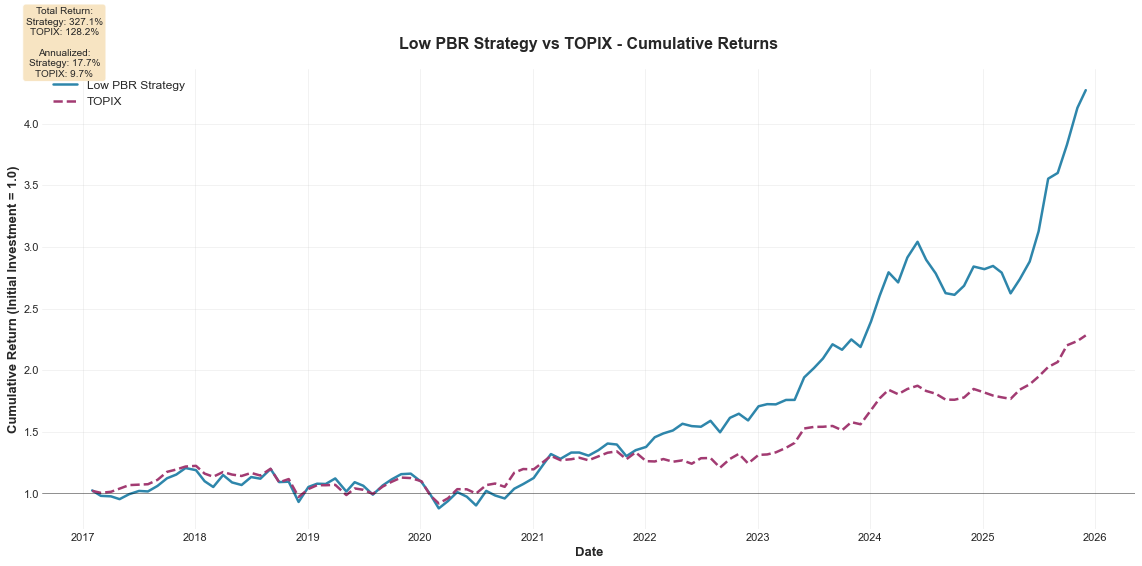


CREATING DRAWDOWN CHART

✓ Drawdown chart created
✓ Saved to: /Users/hiroki/Desktop/EGCapital/JE/Research/PBR/outputs/fig/drawdown_chart.png


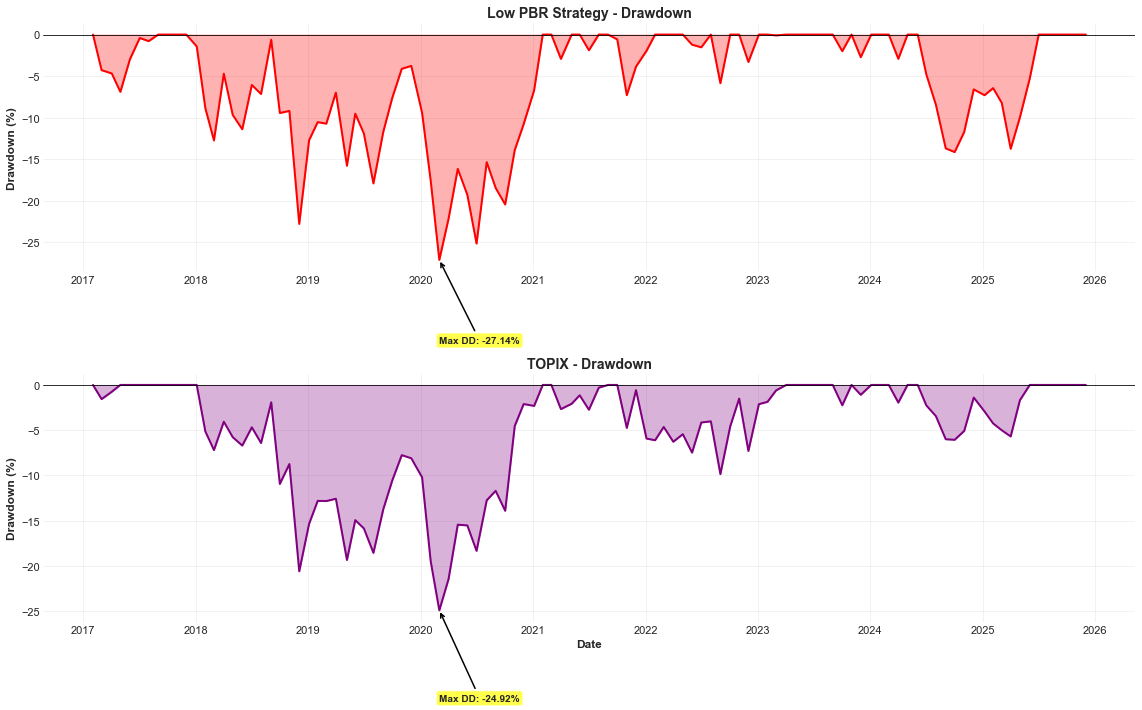


CHART 1/7 COMPLETE - USING ALL 119 MONTHS


In [8]:
# Cell 8

"""
Visualization 1: Cumulative Returns & Drawdown
"""

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# Set style
sns.set_style('whitegrid')

print("="*80)
print("CREATING CUMULATIVE RETURNS & DRAWDOWN CHARTS")
print("="*80)


# Get data from performance_results
strategy_returns = performance_results['strategy_returns']
topix_returns = performance_results['topix_returns']
excess_returns = performance_results['excess_returns']

print(f"\n【Data Check】")
print(f"Strategy returns: {len(strategy_returns)} months")
print(f"TOPIX returns: {len(topix_returns)} months")
print(f"Date range: {strategy_returns.index[0]} to {strategy_returns.index[-1]}")

# ========================================================================
# Calculate Cumulative Returns
# ========================================================================
print("\n" + "="*80)
print("CALCULATING CUMULATIVE RETURNS")
print("="*80)

# Cumulative returns (compounded)
strategy_cumulative = (1 + strategy_returns).cumprod()
topix_cumulative = (1 + topix_returns).cumprod()
excess_cumulative = (1 + excess_returns).cumprod()

print(f"\n✓ Cumulative returns calculated")
print(f"Strategy total return: {(strategy_cumulative.iloc[-1] - 1) * 100:.2f}%")
print(f"TOPIX total return: {(topix_cumulative.iloc[-1] - 1) * 100:.2f}%")
print(f"Excess total return: {(excess_cumulative.iloc[-1] - 1) * 100:.2f}%")

# ========================================================================
# Calculate Drawdowns
# ========================================================================
print("\n" + "="*80)
print("CALCULATING DRAWDOWNS")
print("="*80)

# Strategy drawdown
strategy_rolling_max = strategy_cumulative.expanding().max()
strategy_drawdown = (strategy_cumulative - strategy_rolling_max) / strategy_rolling_max

# TOPIX drawdown
topix_rolling_max = topix_cumulative.expanding().max()
topix_drawdown = (topix_cumulative - topix_rolling_max) / topix_rolling_max

# Max drawdowns
strategy_max_dd = strategy_drawdown.min()
topix_max_dd = topix_drawdown.min()

strategy_max_dd_date = strategy_drawdown.idxmin()
topix_max_dd_date = topix_drawdown.idxmin()

print(f"\n✓ Drawdowns calculated")
print(f"Strategy max drawdown: {strategy_max_dd * 100:.2f}% on {strategy_max_dd_date.strftime('%Y-%m')}")
print(f"TOPIX max drawdown: {topix_max_dd * 100:.2f}% on {topix_max_dd_date.strftime('%Y-%m')}")

# ========================================================================
# FIGURE 1: Cumulative Returns
# ========================================================================
print("\n" + "="*80)
print("CREATING CUMULATIVE RETURNS CHART")
print("="*80)

fig, ax = plt.subplots(figsize=(16, 8))

# Plot cumulative returns
ax.plot(strategy_cumulative.index.to_list(), strategy_cumulative.values, 
        label='Low PBR Strategy', linewidth=2.5, color='#2E86AB')
ax.plot(topix_cumulative.index.to_list(), topix_cumulative.values, 
        label='TOPIX', linewidth=2.5, color='#A23B72', linestyle='--')

# Add horizontal line at 1.0
ax.axhline(y=1.0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

# Format
ax.set_xlabel('Date', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Return (Initial Investment = 1.0)', fontsize=13, fontweight='bold')
ax.set_title('Low PBR Strategy vs TOPIX - Cumulative Returns', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)

# Add summary statistics box
stats_text = f"""Total Return:
Strategy: {(strategy_cumulative.iloc[-1] - 1) * 100:.1f}%
TOPIX: {(topix_cumulative.iloc[-1] - 1) * 100:.1f}%

Annualized:
Strategy: {((strategy_cumulative.iloc[-1]) ** (12/len(strategy_returns)) - 1) * 100:.1f}%
TOPIX: {((topix_cumulative.iloc[-1]) ** (12/len(topix_returns)) - 1) * 100:.1f}%"""

ax.text(0.02, 0.98, stats_text,
        transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom',
        horizontalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()

# Save
output_file = fig_dir / 'cumulative_returns.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Cumulative returns chart created")
print(f"✓ Saved to: {output_file}")

plt.show()

# ========================================================================
# FIGURE 2: Drawdown Chart
# ========================================================================
print("\n" + "="*80)
print("CREATING DRAWDOWN CHART")
print("="*80)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# --------------------------------------------------
# Subplot 1: Strategy Drawdown
# --------------------------------------------------
ax1.fill_between(strategy_drawdown.index.to_list(), strategy_drawdown.values * 100, 0,
                 color='red', alpha=0.3)
ax1.plot(strategy_drawdown.index.to_list(), strategy_drawdown.values * 100,
         color='red', linewidth=2)

ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_ylabel('Drawdown (%)', fontsize=12, fontweight='bold')
ax1.set_title('Low PBR Strategy - Drawdown', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add max drawdown annotation
ax1.annotate(f'Max DD: {strategy_max_dd * 100:.2f}%',
            xy=(strategy_max_dd_date, strategy_max_dd * 100),
            xytext=(strategy_max_dd_date, strategy_max_dd * 100 - 10),
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# --------------------------------------------------
# Subplot 2: TOPIX Drawdown
# --------------------------------------------------
ax2.fill_between(topix_drawdown.index.to_list(), topix_drawdown.values * 100, 0,
                 color='purple', alpha=0.3)
ax2.plot(topix_drawdown.index.to_list(), topix_drawdown.values * 100,
         color='purple', linewidth=2)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Drawdown (%)', fontsize=12, fontweight='bold')
ax2.set_title('TOPIX - Drawdown', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add max drawdown annotation
ax2.annotate(f'Max DD: {topix_max_dd * 100:.2f}%',
            xy=(topix_max_dd_date, topix_max_dd * 100),
            xytext=(topix_max_dd_date, topix_max_dd * 100 - 10),
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

plt.tight_layout()

# Save
output_file = fig_dir / 'drawdown_chart.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Drawdown chart created")
print(f"✓ Saved to: {output_file}")

plt.show()

print("\n" + "="*80)
print("CHART 1/7 COMPLETE - USING ALL 119 MONTHS")
print("="*80)

CREATING MONTHLY RETURNS HEATMAP

【Data Preparation】
Date range: 2017-02-01 00:00:00 to 2025-12-01 00:00:00
Total months: 107

CREATING STRATEGY MONTHLY RETURNS HEATMAP

Monthly returns table shape: (9, 12)
Years covered: 2017 to 2025
Non-null values: 107 out of 108

✓ Strategy monthly returns heatmap created
✓ Saved to: /Users/hiroki/Desktop/EGCapital/JE/Research/PBR/outputs/fig/monthly_returns_heatmap_strategy.png


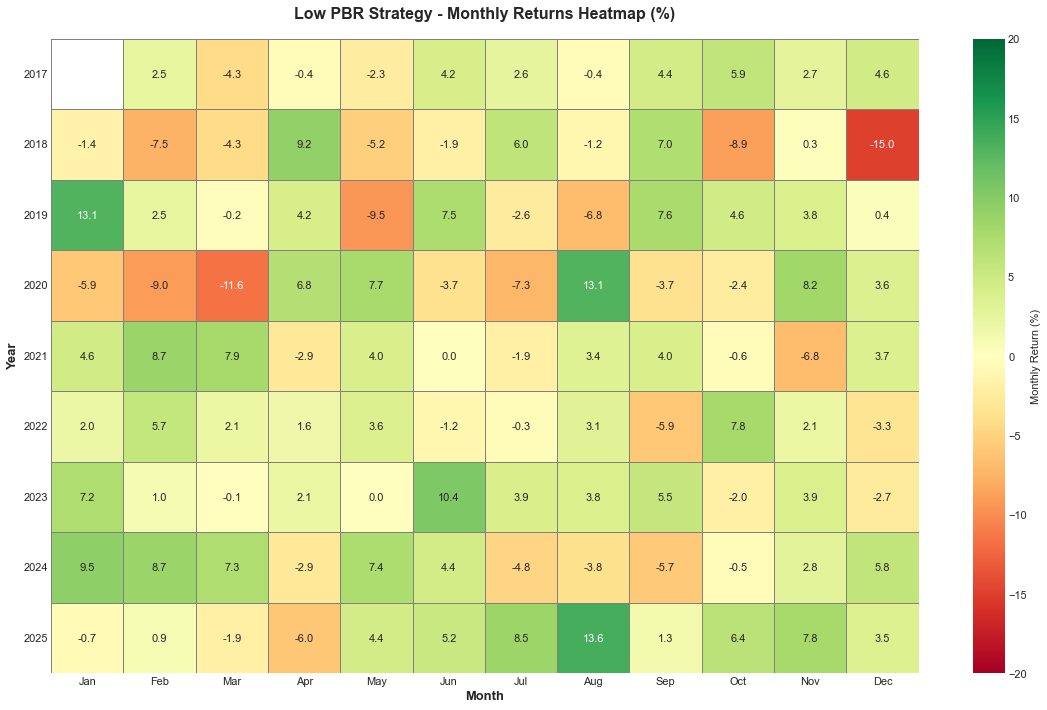


CREATING ALPHA MONTHLY RETURNS HEATMAP

✓ Alpha monthly returns heatmap created
✓ Saved to: /Users/hiroki/Desktop/EGCapital/JE/Research/PBR/outputs/fig/monthly_returns_heatmap_alpha.png


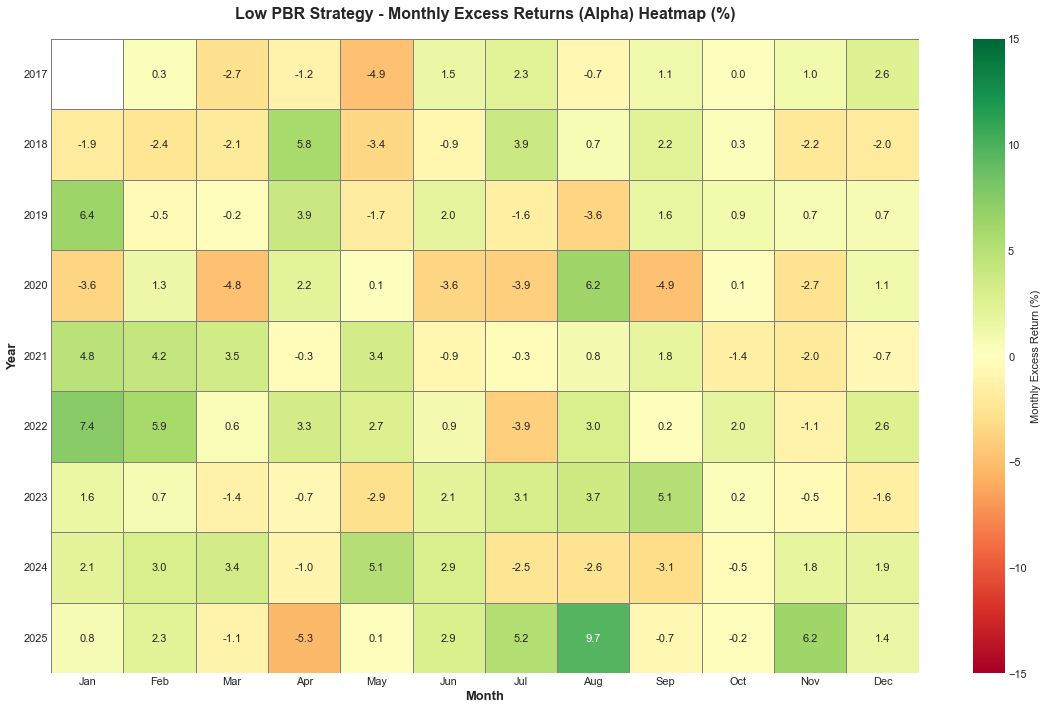


CREATING ANNUAL RETURNS BAR CHART

✓ Annual returns bar chart created
✓ Saved to: /Users/hiroki/Desktop/EGCapital/JE/Research/PBR/outputs/fig/annual_returns_bar_chart.png


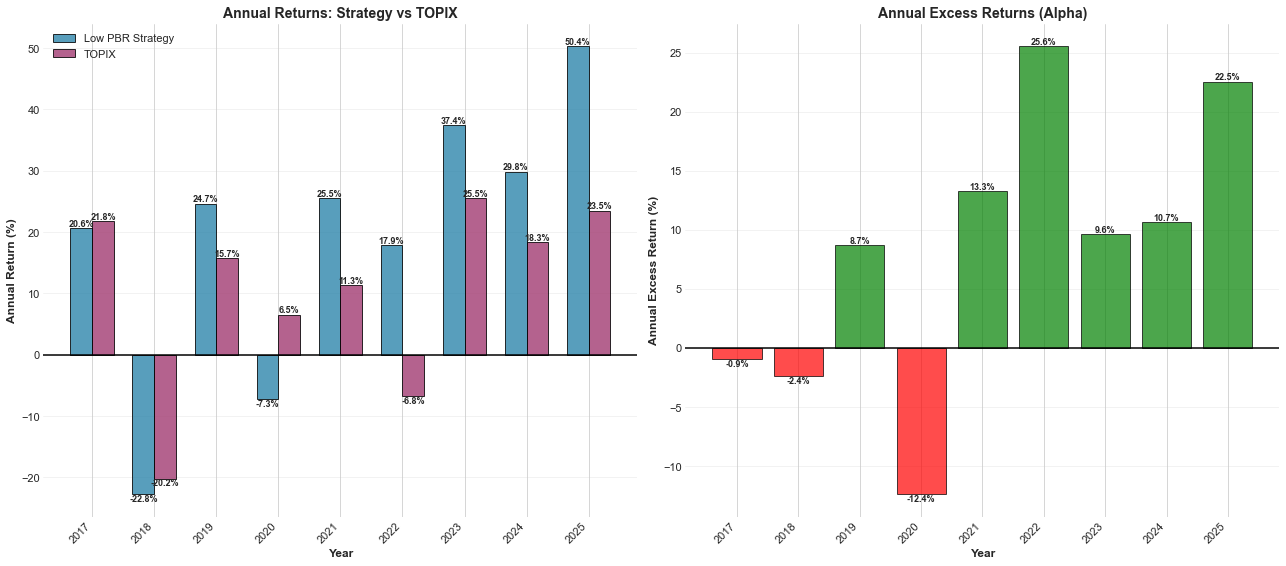


MONTHLY & ANNUAL STATISTICS

【Data Coverage】
Total months: 107
Date range: 2017-02 to 2025-12

【Annual Returns Summary】
      Strategy  TOPIX  Alpha
2017     20.61  21.83  -0.94
2018    -22.80 -20.25  -2.41
2019     24.65  15.74   8.67
2020     -7.29   6.52 -12.42
2021     25.54  11.33  13.27
2022     17.88  -6.77  25.57
2023     37.40  25.55   9.62
2024     29.83  18.35  10.65
2025     50.36  23.52  22.54

【Summary Statistics (Annual)】
Strategy - Mean: 19.58% | Median: 24.65% | Std: 22.23%
TOPIX    - Mean: 10.65% | Median: 15.74% | Std: 15.30%
Alpha    - Mean: 8.28% | Median: 9.62% | Std: 12.06%

【Win Rates (Annual)】
Strategy: 77.8% (7/9 years)
TOPIX:    77.8% (7/9 years)
Alpha:    66.7% (6/9 years)

CHART 2/7 COMPLETE


In [9]:
# Cell 9

"""
Visualization 2: Monthly Returns Heatmap (using monthly_returns DataFrame)
"""

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import pandas as pd

# Set style
sns.set_style('whitegrid')

print("="*80)
print("CREATING MONTHLY RETURNS HEATMAP")
print("="*80)


# ========================================================================
# Prepare Data from monthly_returns
# ========================================================================
print("\n【Data Preparation】")

# Convert ReturnMonth to datetime
monthly_returns['ReturnMonth'] = pd.to_datetime(monthly_returns['ReturnMonth'])

# Extract year and month
monthly_returns['Year'] = monthly_returns['ReturnMonth'].dt.year
monthly_returns['Month'] = monthly_returns['ReturnMonth'].dt.month

# Convert returns to percentage
monthly_returns['Return_pct'] = monthly_returns['NextMonthReturn'] * 100

print(f"Date range: {monthly_returns['ReturnMonth'].min()} to {monthly_returns['ReturnMonth'].max()}")
print(f"Total months: {len(monthly_returns)}")

# Get strategy returns (for TOPIX and Alpha, we'll use performance_results)
strategy_returns = performance_results['strategy_returns']
topix_returns = performance_results['topix_returns']
excess_returns = performance_results['excess_returns']

# ========================================================================
# Helper Function: Create Monthly Returns Table
# ========================================================================
def create_monthly_returns_table_from_df(df, return_col='Return_pct'):
    """
    Create a monthly returns table from DataFrame
    """
    # Create pivot table
    monthly_table = df.pivot_table(
        values=return_col,
        index='Year',
        columns='Month',
        aggfunc='first'
    )
    
    # Ensure all 12 months exist as columns (fill with NaN if missing)
    for month in range(1, 13):
        if month not in monthly_table.columns:
            monthly_table[month] = np.nan
    
    # Sort columns (1-12)
    monthly_table = monthly_table[sorted(monthly_table.columns)]
    
    return monthly_table

def create_monthly_returns_table_from_series(returns_series):
    """
    Create a monthly returns table from Series (for TOPIX and Alpha)
    """
    returns_df = returns_series.to_frame('returns')
    returns_df['Year'] = returns_df.index.year
    returns_df['Month'] = returns_df.index.month
    returns_df['Return_pct'] = returns_df['returns'] * 100
    
    # Create pivot table
    monthly_table = returns_df.pivot_table(
        values='Return_pct',
        index='Year',
        columns='Month',
        aggfunc='first'
    )
    
    # Ensure all 12 months exist as columns
    for month in range(1, 13):
        if month not in monthly_table.columns:
            monthly_table[month] = np.nan
    
    # Sort columns (1-12)
    monthly_table = monthly_table[sorted(monthly_table.columns)]
    
    return monthly_table

# ========================================================================
# FIGURE 1: Strategy Monthly Returns Heatmap
# ========================================================================
print("\n" + "="*80)
print("CREATING STRATEGY MONTHLY RETURNS HEATMAP")
print("="*80)

# Create monthly returns table
monthly_returns_strategy = create_monthly_returns_table_from_df(monthly_returns)

print(f"\nMonthly returns table shape: {monthly_returns_strategy.shape}")
print(f"Years covered: {monthly_returns_strategy.index.min()} to {monthly_returns_strategy.index.max()}")
print(f"Non-null values: {monthly_returns_strategy.notna().sum().sum()} out of {monthly_returns_strategy.size}")

fig, ax = plt.subplots(figsize=(16, 10))

# Create heatmap
sns.heatmap(monthly_returns_strategy, 
            annot=True, 
            fmt='.1f', 
            cmap='RdYlGn', 
            center=0,
            cbar_kws={'label': 'Monthly Return (%)'},
            linewidths=0.5, 
            linecolor='gray',
            vmin=-20, 
            vmax=20,
            ax=ax)

# Format x-axis labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticklabels(month_labels, rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_ylabel('Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=13, fontweight='bold')
ax.set_title('Low PBR Strategy - Monthly Returns Heatmap (%)', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()

# Save
output_file = fig_dir / 'monthly_returns_heatmap_strategy.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Strategy monthly returns heatmap created")
print(f"✓ Saved to: {output_file}")

plt.show()

# ========================================================================
# FIGURE 2: Alpha Monthly Returns Heatmap
# ========================================================================
print("\n" + "="*80)
print("CREATING ALPHA MONTHLY RETURNS HEATMAP")
print("="*80)

# Create monthly returns table for alpha
monthly_returns_alpha = create_monthly_returns_table_from_series(excess_returns)

fig, ax = plt.subplots(figsize=(16, 10))

# Create heatmap
sns.heatmap(monthly_returns_alpha, 
            annot=True, 
            fmt='.1f', 
            cmap='RdYlGn', 
            center=0,
            cbar_kws={'label': 'Monthly Excess Return (%)'},
            linewidths=0.5, 
            linecolor='gray',
            vmin=-15, 
            vmax=15,
            ax=ax)

# Format
ax.set_xticklabels(month_labels, rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_ylabel('Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=13, fontweight='bold')
ax.set_title('Low PBR Strategy - Monthly Excess Returns (Alpha) Heatmap (%)', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()

# Save
output_file = fig_dir / 'monthly_returns_heatmap_alpha.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Alpha monthly returns heatmap created")
print(f"✓ Saved to: {output_file}")

plt.show()

# ========================================================================
# FIGURE 3: TOPIX Monthly Returns Heatmap
# ========================================================================
"""
print("\n" + "="*80)
print("CREATING TOPIX MONTHLY RETURNS HEATMAP")
print("="*80)

# Create monthly returns table for TOPIX
monthly_returns_topix = create_monthly_returns_table_from_series(topix_returns)

fig, ax = plt.subplots(figsize=(16, 10))

# Create heatmap
sns.heatmap(monthly_returns_topix, 
            annot=True, 
            fmt='.1f', 
            cmap='RdYlGn', 
            center=0,
            cbar_kws={'label': 'Monthly Return (%)'},
            linewidths=0.5, 
            linecolor='gray',
            vmin=-20, 
            vmax=20,
            ax=ax)

# Format
ax.set_xticklabels(month_labels, rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_ylabel('Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=13, fontweight='bold')
ax.set_title('TOPIX - Monthly Returns Heatmap (%)', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()

# Save
output_file = fig_dir / 'monthly_returns_heatmap_topix.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ TOPIX monthly returns heatmap created")
print(f"✓ Saved to: {output_file}")

plt.show()
"""

# ========================================================================
# FIGURE 4: Annual Returns Bar Chart
# ========================================================================
print("\n" + "="*80)
print("CREATING ANNUAL RETURNS BAR CHART")
print("="*80)

# Calculate annual returns from monthly_returns DataFrame
annual_strategy = monthly_returns.groupby('Year')['NextMonthReturn'].apply(
    lambda x: ((1 + x).prod() - 1) * 100
)

# Calculate annual returns for TOPIX and Alpha
def calculate_annual_returns(returns_series):
    """Calculate annual returns using compound returns"""
    returns_df = returns_series.to_frame('returns')
    returns_df['year'] = returns_df.index.year
    
    annual_returns = returns_df.groupby('year')['returns'].apply(
        lambda x: ((1 + x).prod() - 1) * 100
    )
    
    return annual_returns

annual_topix = calculate_annual_returns(topix_returns)
annual_alpha = calculate_annual_returns(excess_returns)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --------------------------------------------------
# Subplot 1: Annual Returns (Strategy vs TOPIX)
# --------------------------------------------------
years = annual_strategy.index
x = np.arange(len(years))
width = 0.35

bars1 = ax1.bar(x - width/2, annual_strategy.values, width, 
                label='Low PBR Strategy', color='#2E86AB', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x + width/2, annual_topix.values, width,
                label='TOPIX', color='#A23B72', alpha=0.8, edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom' if height > 0 else 'top',
                fontsize=9, fontweight='bold')

ax1.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Annual Return (%)', fontsize=12, fontweight='bold')
ax1.set_title('Annual Returns: Strategy vs TOPIX', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(years, rotation=45, ha='right')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')

# --------------------------------------------------
# Subplot 2: Annual Excess Returns (Alpha)
# --------------------------------------------------
colors = ['green' if val > 0 else 'red' for val in annual_alpha.values]
bars3 = ax2.bar(annual_alpha.index, annual_alpha.values, color=colors, alpha=0.7, edgecolor='black')

# Add value labels
for year, value in zip(annual_alpha.index, annual_alpha.values):
    ax2.text(year, value, f'{value:.1f}%',
            ha='center', va='bottom' if value > 0 else 'top',
            fontsize=9, fontweight='bold')

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Annual Excess Return (%)', fontsize=12, fontweight='bold')
ax2.set_title('Annual Excess Returns (Alpha)', fontsize=14, fontweight='bold')
ax2.set_xticks(annual_alpha.index)
ax2.set_xticklabels(annual_alpha.index, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Save
output_file = fig_dir / 'annual_returns_bar_chart.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Annual returns bar chart created")
print(f"✓ Saved to: {output_file}")

plt.show()

# ========================================================================
# Print Statistics
# ========================================================================
print("\n" + "="*80)
print("MONTHLY & ANNUAL STATISTICS")
print("="*80)

print("\n【Data Coverage】")
print(f"Total months: {len(monthly_returns)}")
print(f"Date range: {monthly_returns['ReturnMonth'].min().strftime('%Y-%m')} to {monthly_returns['ReturnMonth'].max().strftime('%Y-%m')}")

print("\n【Annual Returns Summary】")
summary_df = pd.DataFrame({
    'Strategy': annual_strategy,
    'TOPIX': annual_topix,
    'Alpha': annual_alpha
})
print(summary_df.to_string())

print("\n【Summary Statistics (Annual)】")
print(f"Strategy - Mean: {annual_strategy.mean():.2f}% | Median: {annual_strategy.median():.2f}% | Std: {annual_strategy.std():.2f}%")
print(f"TOPIX    - Mean: {annual_topix.mean():.2f}% | Median: {annual_topix.median():.2f}% | Std: {annual_topix.std():.2f}%")
print(f"Alpha    - Mean: {annual_alpha.mean():.2f}% | Median: {annual_alpha.median():.2f}% | Std: {annual_alpha.std():.2f}%")

# Win rates
win_rate_strategy = (annual_strategy > 0).sum() / len(annual_strategy) * 100
win_rate_topix = (annual_topix > 0).sum() / len(annual_topix) * 100
win_rate_alpha = (annual_alpha > 0).sum() / len(annual_alpha) * 100

print(f"\n【Win Rates (Annual)】")
print(f"Strategy: {win_rate_strategy:.1f}% ({(annual_strategy > 0).sum()}/{len(annual_strategy)} years)")
print(f"TOPIX:    {win_rate_topix:.1f}% ({(annual_topix > 0).sum()}/{len(annual_topix)} years)")
print(f"Alpha:    {win_rate_alpha:.1f}% ({(annual_alpha > 0).sum()}/{len(annual_alpha)} years)")

print("\n" + "="*80)
print("CHART 2/7 COMPLETE")
print("="*80)

## Cell 10: Portfolio Characteristics

### Purpose
Analyze portfolio composition and turnover characteristics using TOPIX-33 sector classification.

### Methodology

#### Sector Exposure Analysis
```python
# Add TOPIX-33 sector names (English translation)
SECTOR_NAME_EN = {
    '銀行業': 'Banks',
    '電気機器': 'Electric Appliances',
    ...
}

# Calculate monthly sector exposure (equal-weighted)
sector_exposure = portfolios.groupby(['MonthEnd', 'Sector']).size()
sector_exposure_pct = (sector_exposure / 10) * 100  # 10 stocks per portfolio
```

#### Turnover Calculation
```python
for each month:
    prev_stocks = set(previous_month_portfolio)
    curr_stocks = set(current_month_portfolio)
    
    stocks_out = prev_stocks - curr_stocks
    stocks_in = curr_stocks - prev_stocks
    
    turnover_rate = len(stocks_out) / len(prev_stocks)
```

### Visualizations

1. **All Sectors Stacked Area (100%)**
   - Shows complete sector composition over time
   - All 33 TOPIX sectors displayed
   - Identifies sector concentration risks

2. **Top 10 Sectors Line Chart**
   - Highlights main sector exposures
   - Tracks sector rotation patterns

3. **Turnover Analysis**
   - Upper panel: Monthly turnover rate (%)
   - Lower panel: Entry/Exit stock counts
   - Identifies portfolio stability

4. **Turnover Distribution**
   - Histogram of monthly turnover
   - Mean and median markers

### Key Insights
- **Average Turnover**: 9.6% monthly (low → stable holdings)
- **Top Sector Exposures**: Banks, Electric Appliances, Transportation Equipment
- **Sector Concentration**: Monitored via Herfindahl Index

### Output Files
- `portfolio_characteristics.pdf`: 4 charts
- `sector_exposure_timeseries.csv`: Monthly sector weights
- `portfolio_turnover.csv`: Monthly turnover statistics

STEP 10: PORTFOLIO CHARACTERISTICS ANALYSIS

【1. Loading Sector Classification】
Sector mapping loaded: 4657 stocks
Unique sectors: 34

【Sector Distribution】
S33Nm_EN
Information & Communication    676
Services                       617
Others                         494
Retail Trade                   375
Wholesale Trade                322
Electric Appliances            245
Machinery                      224
Chemicals                      213
Construction                   174
Real Estate                    173
Name: count, dtype: int64

【2. Adding Sector Information to Portfolios】
Portfolios with sector: 1080
Missing sector info: 0

【3. Calculating Sector Exposure】
Sector exposure calculated: 108 months
Tracked sectors: 15

【Top 10 Sectors by Average Exposure】
  Transportation Equipment                :  19.6%
  Information & Communication             :  12.5%
  Insurance                               :  12.5%
  Electric Appliances                     :  10.7%
  Iron & Steel           

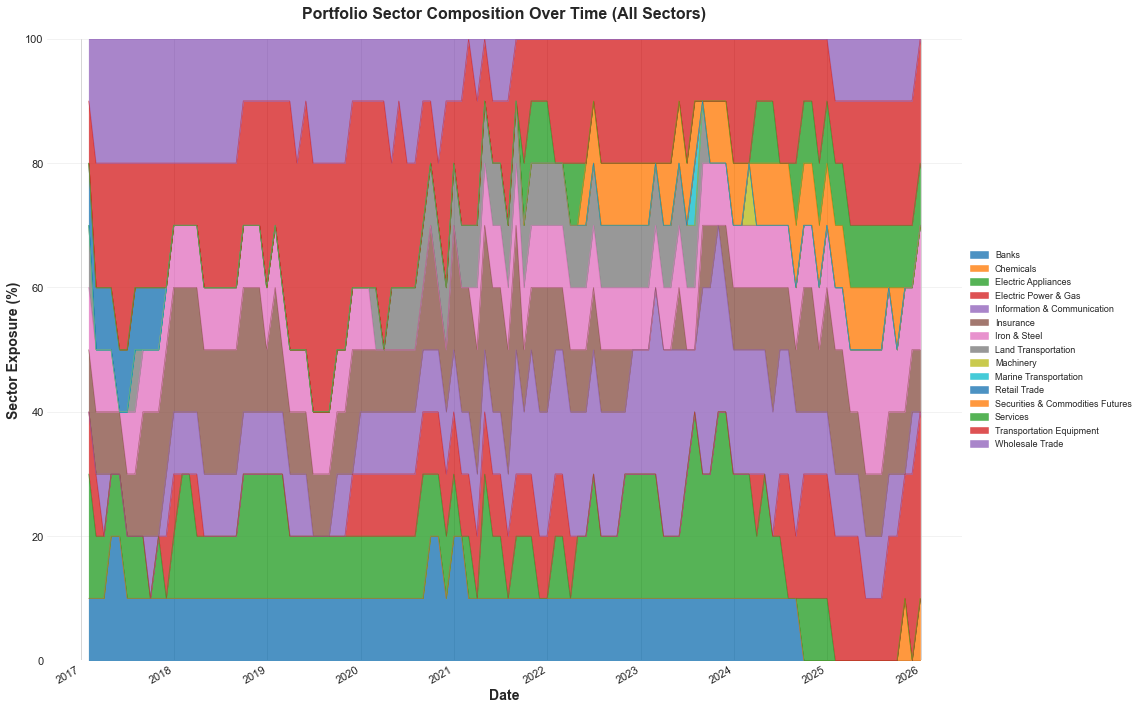

  Chart 2: Portfolio Turnover


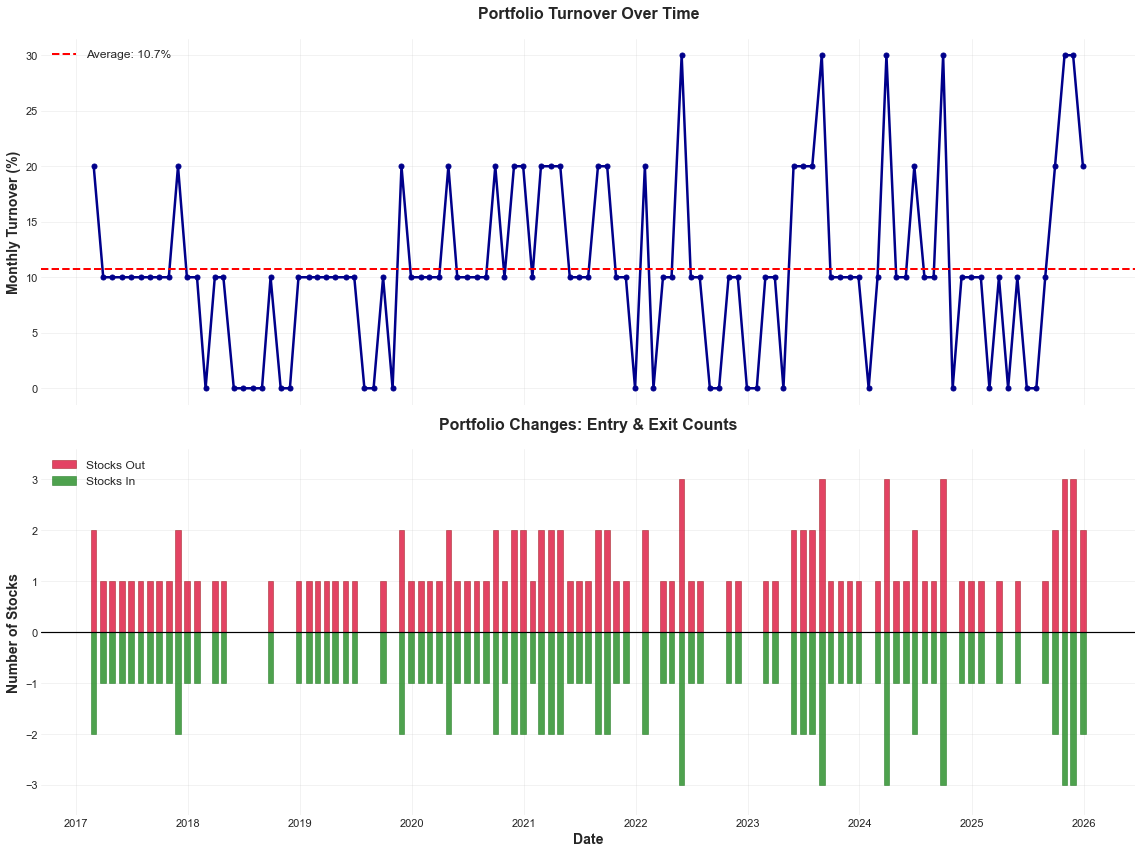

  Chart 3: Turnover Distribution


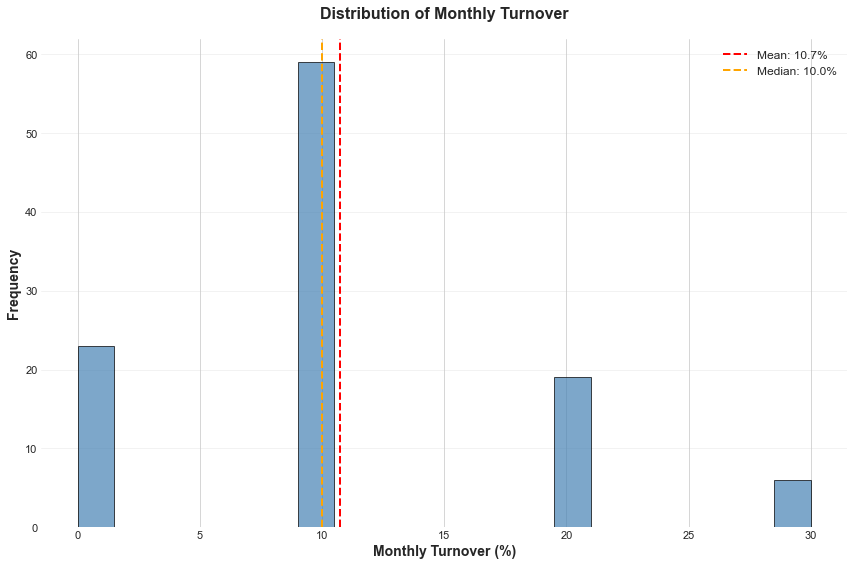


✓ Visualizations saved to: /Users/hiroki/Desktop/EGCapital/JE/Research/PBR/outputs/tables/portfolio_characteristics.pdf

【6. Saving Results】
  ✓ Sector exposure: sector_exposure_timeseries.csv
  ✓ Turnover data: portfolio_turnover.csv

【7. Summary Statistics】
                   Metric Value
     Average Turnover (%) 10.75
      Median Turnover (%) 10.00
         Min Turnover (%)  0.00
         Max Turnover (%) 30.00
 Avg Stocks Out per Month   1.1
  Avg Stocks In per Month   1.1
Avg Stocks Held per Month   8.9
           Portfolio Size    10

【Top 10 Sector Exposures (Average)】
   1. Transportation Equipment                : 19.63%
   2. Information & Communication             : 12.50%
   3. Insurance                               : 12.50%
   4. Electric Appliances                     : 10.74%
   5. Iron & Steel                            :  9.26%
   6. Banks                                   :  9.07%
   7. Wholesale Trade                         :  8.61%
   8. Electric Power & Gas   

In [10]:
# Cell 10 - Portfolio Characteristics Analysis (English Version)

"""
Step 10: Portfolio Characteristics
- All sectors stacked area chart (100%)
- Portfolio turnover over time
- Entry/Exit stock counts
- Full English labels for international presentation
"""

print("="*80)
print("STEP 10: PORTFOLIO CHARACTERISTICS ANALYSIS")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# ========================================================================
# Sector Name Translation (Japanese to English)
# ========================================================================
SECTOR_NAME_EN = {
    '水産・農林業': 'Fishery & Forestry',
    '鉱業': 'Mining',
    '建設業': 'Construction',
    '食料品': 'Foods',
    '繊維製品': 'Textiles & Apparel',
    'パルプ・紙': 'Pulp & Paper',
    '化学': 'Chemicals',
    '医薬品': 'Pharmaceuticals',
    '石油･石炭製品': 'Oil & Coal Products',
    'ゴム製品': 'Rubber Products',
    'ガラス･土石製品': 'Glass & Ceramics',
    '鉄鋼': 'Iron & Steel',
    '非鉄金属': 'Nonferrous Metals',
    '金属製品': 'Metal Products',
    '機械': 'Machinery',
    '電気機器': 'Electric Appliances',
    '輸送用機器': 'Transportation Equipment',
    '精密機器': 'Precision Instruments',
    'その他製品': 'Other Products',
    '電気･ガス業': 'Electric Power & Gas',
    '陸運業': 'Land Transportation',
    '海運業': 'Marine Transportation',
    '空運業': 'Air Transportation',
    '倉庫･運輸関連業': 'Warehousing & Harbor Transportation',
    '情報･通信業': 'Information & Communication',
    '卸売業': 'Wholesale Trade',
    '小売業': 'Retail Trade',
    '銀行業': 'Banks',
    '証券･商品先物取引業': 'Securities & Commodities Futures',
    '保険業': 'Insurance',
    'その他金融業': 'Other Financing Business',
    '不動産業': 'Real Estate',
    'サービス業': 'Services',
    'その他': 'Others',
    'その他/不明': 'Others/Unknown'
}

# ========================================================================
# 1. Load Sector Data (TOPIX-33 Sector Classification)
# ========================================================================
print("\n【1. Loading Sector Classification】")

# J-Quants master data has S33 and S33Nm
sector_mapping = master[['Code', 'S33', 'S33Nm']].drop_duplicates('Code')

print(f"Sector mapping loaded: {len(sector_mapping)} stocks")
print(f"Unique sectors: {sector_mapping['S33Nm'].nunique()}")

# Translate sector names to English
sector_mapping['S33Nm_EN'] = sector_mapping['S33Nm'].map(SECTOR_NAME_EN)
sector_mapping['S33Nm_EN'] = sector_mapping['S33Nm_EN'].fillna('Others/Unknown')

# Show sector distribution
print("\n【Sector Distribution】")
sector_counts = sector_mapping['S33Nm_EN'].value_counts()
print(sector_counts.head(10))

# ========================================================================
# 2. Add Sector Information to Portfolios
# ========================================================================
print("\n【2. Adding Sector Information to Portfolios】")

# Merge sector info with portfolios
portfolios_with_sector = complete_portfolios.merge(
    sector_mapping[['Code', 'S33Nm_EN']],
    on='Code',
    how='left'
)

print(f"Portfolios with sector: {len(portfolios_with_sector)}")
print(f"Missing sector info: {portfolios_with_sector['S33Nm_EN'].isna().sum()}")

# Fill missing sectors
portfolios_with_sector['S33Nm_EN'] = portfolios_with_sector['S33Nm_EN'].fillna('Others/Unknown')

# ========================================================================
# 3. Calculate Sector Exposure Over Time
# ========================================================================
print("\n【3. Calculating Sector Exposure】")

# Calculate equal-weighted sector exposure (# stocks per sector / total stocks)
sector_exposure = portfolios_with_sector.groupby(['MonthEnd', 'S33Nm_EN']).size().unstack(fill_value=0)

# Convert to percentages
sector_exposure_pct = sector_exposure.div(sector_exposure.sum(axis=1), axis=0) * 100

print(f"Sector exposure calculated: {len(sector_exposure_pct)} months")
print(f"Tracked sectors: {len(sector_exposure_pct.columns)}")

# Get top sectors by average exposure
top_sectors = sector_exposure_pct.mean().sort_values(ascending=False).head(10)
print("\n【Top 10 Sectors by Average Exposure】")
for sector, pct in top_sectors.items():
    print(f"  {sector:40s}: {pct:5.1f}%")

# ========================================================================
# 4. Calculate Portfolio Turnover
# ========================================================================
print("\n【4. Calculating Portfolio Turnover】")

# Sort portfolios by date
portfolios_sorted = portfolios_with_sector.sort_values('MonthEnd')

# Calculate turnover month-by-month
turnover_data = []
month_ends = sorted(portfolios_sorted['MonthEnd'].unique())

for i in range(1, len(month_ends)):
    prev_month_end = month_ends[i-1]
    curr_month_end = month_ends[i]
    
    prev_stocks = set(portfolios_sorted[portfolios_sorted['MonthEnd'] == prev_month_end]['Code'])
    curr_stocks = set(portfolios_sorted[portfolios_sorted['MonthEnd'] == curr_month_end]['Code'])
    
    # Calculate changes
    stocks_out = prev_stocks - curr_stocks  # Exited
    stocks_in = curr_stocks - prev_stocks   # Entered
    stocks_hold = prev_stocks & curr_stocks # Held
    
    # Turnover rate (stocks changed / portfolio size)
    portfolio_size = len(prev_stocks)
    turnover_rate = len(stocks_out) / portfolio_size if portfolio_size > 0 else 0
    
    turnover_data.append({
        'MonthEnd': curr_month_end,
        'Turnover': turnover_rate * 100,  # Percentage
        'StocksOut': len(stocks_out),
        'StocksIn': len(stocks_in),
        'StocksHold': len(stocks_hold),
        'PortfolioSize': len(curr_stocks)
    })

turnover_df = pd.DataFrame(turnover_data)

print(f"Turnover calculated: {len(turnover_df)} months")
print(f"\n【Turnover Statistics】")
print(f"  Average: {turnover_df['Turnover'].mean():.1f}%")
print(f"  Median: {turnover_df['Turnover'].median():.1f}%")
print(f"  Min: {turnover_df['Turnover'].min():.1f}%")
print(f"  Max: {turnover_df['Turnover'].max():.1f}%")

print(f"\n【Stock Changes】")
print(f"  Avg stocks out: {turnover_df['StocksOut'].mean():.1f}")
print(f"  Avg stocks in: {turnover_df['StocksIn'].mean():.1f}")
print(f"  Avg stocks held: {turnover_df['StocksHold'].mean():.1f}")

# ========================================================================
# 5. Visualization
# ========================================================================
print("\n【5. Creating Visualizations】")

# Create PDF output
pdf_path = tables_dir / 'portfolio_characteristics.pdf'

with PdfPages(pdf_path) as pdf:
    
    # ====================================================================
    # Chart 1: All Sectors Stacked Area (100%)
    # ====================================================================
    print("  Chart 1: All Sectors Stacked Area Chart")
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Plot ALL sectors as stacked area
    sector_exposure_pct.plot.area(
        ax=ax, 
        stacked=True, 
        alpha=0.8,
        legend=True,
        linewidth=0.5
    )
    
    ax.set_xlabel('Date', fontsize=14, fontweight='bold')
    ax.set_ylabel('Sector Exposure (%)', fontsize=14, fontweight='bold')
    ax.set_title('Portfolio Sector Composition Over Time (All Sectors)', fontsize=16, fontweight='bold', pad=20)
    ax.set_ylim(0, 100)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9, ncol=1)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.show()  # Display in notebook
    plt.close(fig)
    
    """
    # ====================================================================
    # Chart XX: Top 10 Sectors Line Chart
    # ====================================================================
    print("  Chart XX: Top 10 Sectors Line Chart")
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Plot top 10 sectors as lines
    top_10_sectors = sector_exposure_pct.mean().sort_values(ascending=False).head(10).index
    
    # Convert index to array for matplotlib compatibility
    x_dates = sector_exposure_pct.index.to_numpy()
    
    for sector in top_10_sectors:
        y_values = sector_exposure_pct[sector].to_numpy()
        ax.plot(x_dates, y_values, 
                label=sector, linewidth=2.5, marker='o', markersize=4, alpha=0.8)
    
    ax.set_xlabel('Date', fontsize=14, fontweight='bold')
    ax.set_ylabel('Sector Exposure (%)', fontsize=14, fontweight='bold')
    ax.set_title('Sector Exposure Over Time (Top 10 Sectors)', fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.show()  # Display in notebook
    plt.close(fig)
    """
    
    # ====================================================================
    # Chart 2: Portfolio Turnover Over Time
    # ====================================================================
    print("  Chart 2: Portfolio Turnover")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    
    # Convert to arrays for matplotlib compatibility
    x_turnover = turnover_df['MonthEnd'].to_numpy()
    
    # Top panel: Turnover rate (line)
    ax1.plot(x_turnover, turnover_df['Turnover'].to_numpy(), 
             color='darkblue', linewidth=2.5, marker='o', markersize=5)
    ax1.axhline(y=turnover_df['Turnover'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f'Average: {turnover_df["Turnover"].mean():.1f}%')
    ax1.set_ylabel('Monthly Turnover (%)', fontsize=14, fontweight='bold')
    ax1.set_title('Portfolio Turnover Over Time', fontsize=16, fontweight='bold', pad=20)
    ax1.legend(loc='best', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Bottom panel: Entry/Exit counts (bar)
    if len(x_turnover) > 1:
        avg_spacing = (x_turnover[-1] - x_turnover[0]) / len(x_turnover)
        width = avg_spacing * 0.6  # 60% of average spacing
    else:
        width = pd.Timedelta(days=15)
    
    # Plot as separate bars (out as positive, in as negative for visual separation)
    ax2.bar(x_turnover, turnover_df['StocksOut'].to_numpy(), width=width, 
            label='Stocks Out', color='crimson', alpha=0.8, edgecolor='darkred', linewidth=0.5)
    ax2.bar(x_turnover, -turnover_df['StocksIn'].to_numpy(), width=width, 
            label='Stocks In', color='forestgreen', alpha=0.8, edgecolor='darkgreen', linewidth=0.5)
    
    ax2.axhline(y=0, color='black', linewidth=1.2)
    ax2.set_xlabel('Date', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of Stocks', fontsize=14, fontweight='bold')
    ax2.set_title('Portfolio Changes: Entry & Exit Counts', fontsize=16, fontweight='bold', pad=20)
    ax2.legend(loc='best', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # Set y-axis limits to show small values clearly
    max_val = max(turnover_df['StocksOut'].max(), turnover_df['StocksIn'].max())
    ax2.set_ylim(-max_val * 1.2, max_val * 1.2)
    
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.show()  # Display in notebook
    plt.close(fig)
    
    # ====================================================================
    # Chart 3: Turnover Distribution (Histogram)
    # ====================================================================
    print("  Chart 3: Turnover Distribution")
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Convert to array
    turnover_values = turnover_df['Turnover'].to_numpy()
    
    ax.hist(turnover_values, bins=20, color='steelblue', 
            edgecolor='black', alpha=0.7)
    ax.axvline(x=turnover_df['Turnover'].mean(), color='red', 
               linestyle='--', linewidth=2, label=f'Mean: {turnover_df["Turnover"].mean():.1f}%')
    ax.axvline(x=turnover_df['Turnover'].median(), color='orange', 
               linestyle='--', linewidth=2, label=f'Median: {turnover_df["Turnover"].median():.1f}%')
    
    ax.set_xlabel('Monthly Turnover (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=14, fontweight='bold')
    ax.set_title('Distribution of Monthly Turnover', fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.show()  # Display in notebook
    plt.close(fig)

print(f"\n✓ Visualizations saved to: {pdf_path}")

# ========================================================================
# 6. Save Results to CSV
# ========================================================================
print("\n【6. Saving Results】")

# Save sector exposure
sector_exposure_pct.to_csv(processed_dir / 'sector_exposure_timeseries.csv')
print(f"  ✓ Sector exposure: sector_exposure_timeseries.csv")

# Save turnover data
turnover_df.to_csv(processed_dir /'portfolio_turnover.csv', index=False)
print(f"  ✓ Turnover data: portfolio_turnover.csv")

# ========================================================================
# 7. Summary Statistics Table
# ========================================================================
print("\n【7. Summary Statistics】")

summary_stats = pd.DataFrame({
    'Metric': [
        'Average Turnover (%)',
        'Median Turnover (%)',
        'Min Turnover (%)',
        'Max Turnover (%)',
        'Avg Stocks Out per Month',
        'Avg Stocks In per Month',
        'Avg Stocks Held per Month',
        'Portfolio Size'
    ],
    'Value': [
        f"{turnover_df['Turnover'].mean():.2f}",
        f"{turnover_df['Turnover'].median():.2f}",
        f"{turnover_df['Turnover'].min():.2f}",
        f"{turnover_df['Turnover'].max():.2f}",
        f"{turnover_df['StocksOut'].mean():.1f}",
        f"{turnover_df['StocksIn'].mean():.1f}",
        f"{turnover_df['StocksHold'].mean():.1f}",
        f"{turnover_df['PortfolioSize'].iloc[-1]}"
    ]
})

print(summary_stats.to_string(index=False))

# Top sector exposures (average over time)
print("\n【Top 10 Sector Exposures (Average)】")
top_sector_summary = sector_exposure_pct.mean().sort_values(ascending=False).head(10)
for i, (sector, pct) in enumerate(top_sector_summary.items(), 1):
    print(f"  {i:2d}. {sector:40s}: {pct:5.2f}%")

print("\n" + "="*80)
print("STEP 10 COMPLETE")
print("="*80)
print(f"\nOutputs:")
print(f"  - {pdf_path}")
print(f"  - sector_exposure_timeseries.csv")
print(f"  - portfolio_turnover.csv")

## Cell 11: Advanced Analysis

### Purpose
Comprehensive risk analysis using rolling metrics, factor exposure analysis, Monte Carlo simulation, and benchmark comparison.

### Components

#### 1. Rolling Metrics (6-Month Window)

**Calculation**:
```python
window = 6  # months

for i in range(6, len(monthly_returns) + 1):
    window_data = monthly_returns[i-6:i]  # Last 6 months
    
    beta = cov(strategy, topix) / var(topix)
    IR = mean(excess) / std(excess)
    sharpe = (mean(strategy) / std(strategy)) * sqrt(12)
```

**Purpose**:
- Detect regime changes
- Monitor strategy stability
- Identify periods of outperformance/underperformance

**Timeline**: 2017-06 to 2025-12 (103 rolling windows)

#### 2. Factor Exposure Analysis

**Russell/Nomura Indices Used**:
- Large / Large Value / Large Growth
- Mid-Small
- Small / Small Value / Small Growth

**Methodology**:
```python
for each factor:
    correlation = corr(strategy_returns, factor_returns)
```

**Interpretation**:
- High correlation with Large Value → Value factor exposure
- Low correlation with Growth → Pure value play
- Correlation with Size factors → Market cap bias

#### 3. Rolling Factor Exposures

**Key Factors Tracked** (6-month rolling):
- Large Value
- Large Growth  
- Small Value

**Purpose**: Detect factor drift over time

#### 4. Monte Carlo Simulation

**Parameters**:
- Simulations: 10,000 paths
- Horizon: 60 months (5 years)
- Distribution: Normal(μ, σ) from historical returns

**Calculation**:
```python
for each simulation:
    random_returns = np.random.normal(mean_return, std_return, 60)
    cumulative_wealth = np.cumprod(1 + random_returns)
```

**Output Percentiles**:
- 5th percentile (downside scenario)
- 25th percentile
- 50th percentile (median)
- 75th percentile
- 95th percentile (upside scenario)

**Interpretation**:
- 5th percentile: 5% chance of worse outcome
- 95th percentile: 5% chance of better outcome
- Range between 25th-75th: ~50% probability

#### 5. Cumulative Return Comparison

**Benchmarks**:
- TOPIX (broad market)
- Russell/Nomura Top Value (Top 50% large-cap of Market capitalization, value factor)
- Russell/Nomura Top (Top 50% large-cap of Market capitalization)
- Russell/Nomura Large Value (Top 85% large-cap of Market capitalizatio, value factor)

**Calculation**:
```python
cumulative = (1 + monthly_returns).cumprod()
```

**Visual**: Line chart showing wealth accumulation ($1.00 start)

### Output Files
- `advanced_analysis.pdf`: 5 comprehensive charts
- `rolling_metrics.csv`: Beta, IR, Sharpe over time
- `factor_exposures.csv`: Static factor correlations
- `rolling_factor_exposures.csv`: Time-varying factor exposures
- `monte_carlo_simulation.csv`: Percentile projections

STEP 11: ADVANCED PERFORMANCE ANALYSIS

【1. Loading Russell/Nomura Index Data】
Russell/Nomura data loaded: 553 days
Date range: 1979-12-01 00:00:00 to 2025-12-01 00:00:00

Key indices available:
  ✓ Top
  ✓ Mid-Small
  ✓ Total Market Value
  ✓ Total Market Growth
  ✓ Top Value
  ✓ Large Value

【2. Calculating Monthly Returns】
Monthly returns calculated: 553 months
Merged analysis data: 107 months

【3. Calculating Rolling Metrics (6-month rolling window)】
Rolling metrics calculated: 102 periods
  First date: 2017-07-03 00:00:00
  Last date: 2025-12-01 00:00:00

【Average Rolling Metrics】
  Beta (vs TOPIX):      1.261
  Information Ratio:    0.256
  Sharpe Ratio (ann.):  1.316

【4. Factor Exposure Analysis】
  Correlation with Top                 :  0.780
  Correlation with Mid-Small           :  0.816
  Correlation with Total Market Value  :  0.911
  Correlation with Total Market Growth :  0.608
  Correlation with Top Value           :  0.866
  Correlation with Large Value         :  0.90

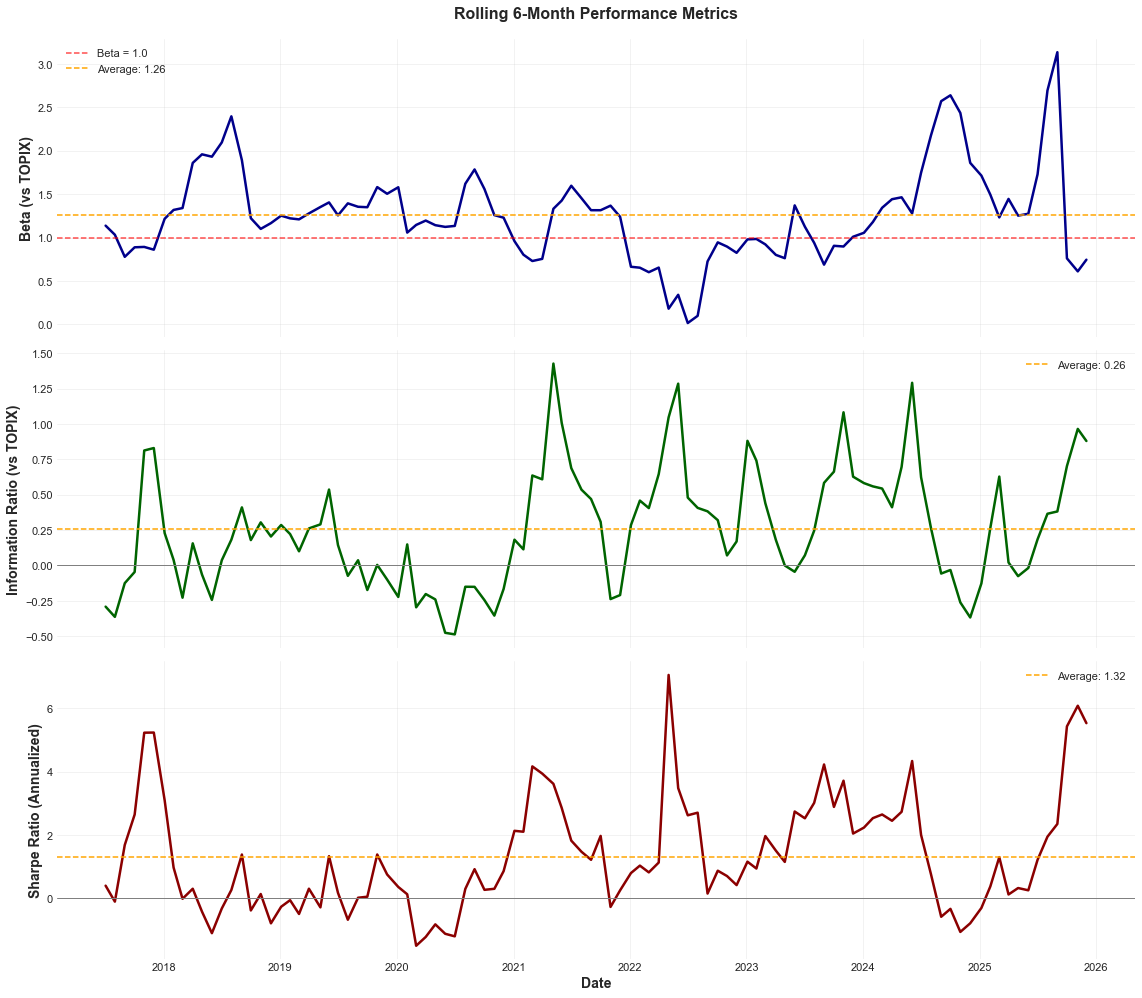

  Chart 2: Factor Exposures (Style & Size)


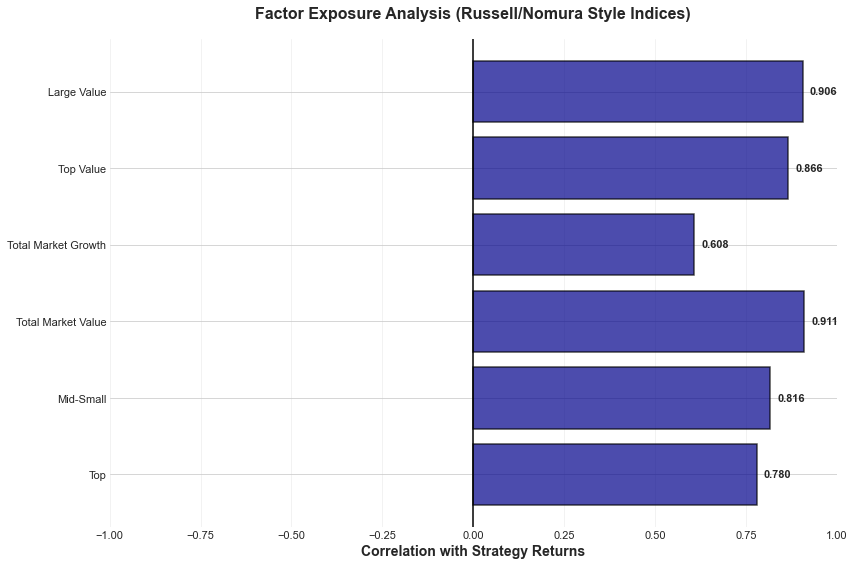

  Chart 3: Rolling Factor Exposures


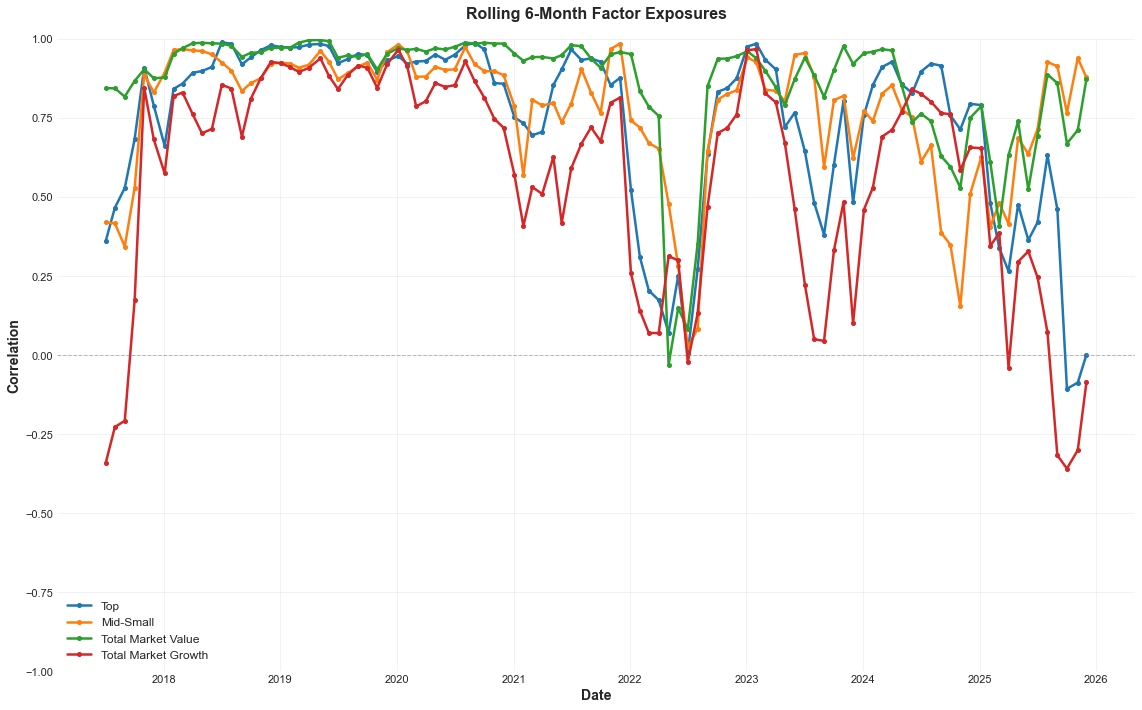

  Chart 4: Monte Carlo Simulation


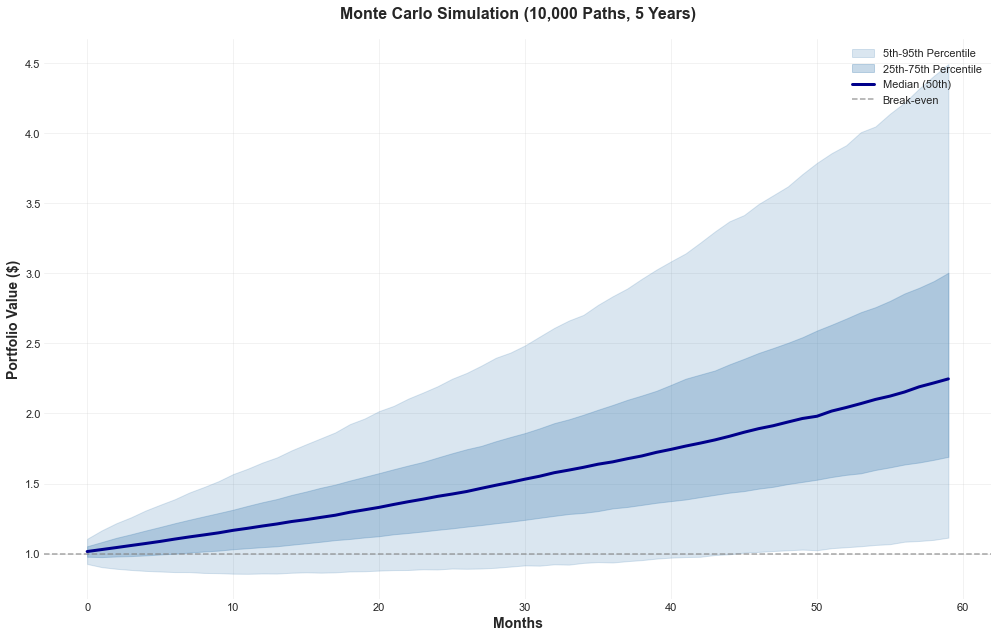

  Chart 5: Cumulative Returns vs Benchmarks


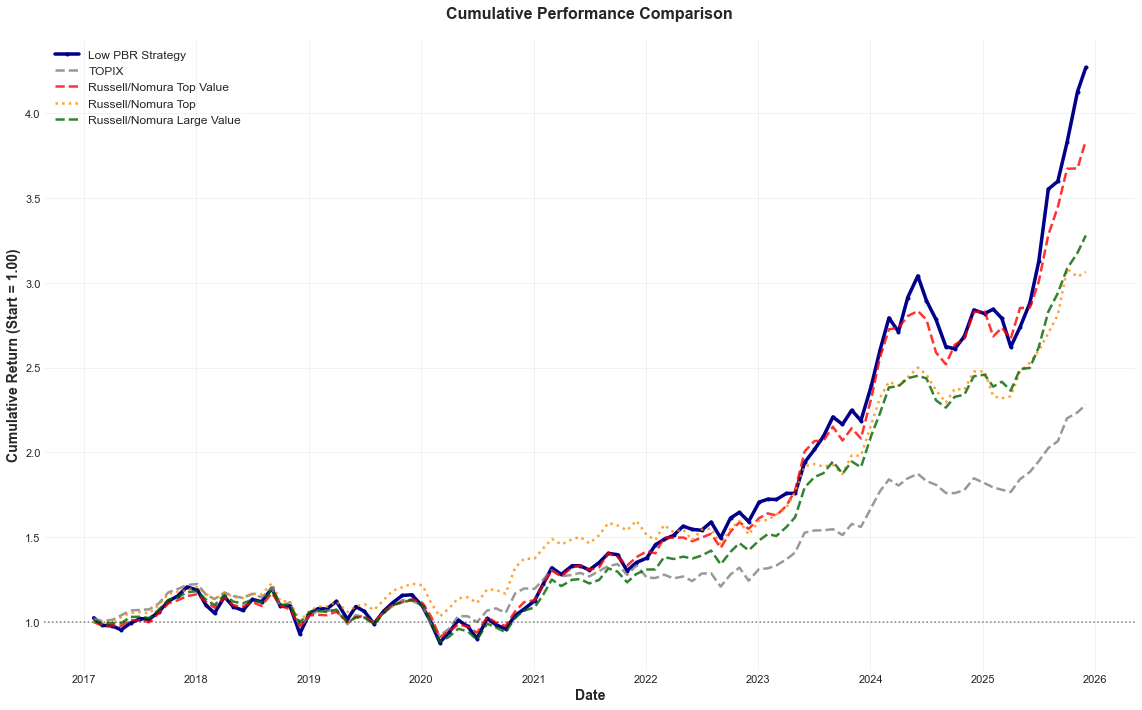


✓ Visualizations saved to: /Users/hiroki/Desktop/EGCapital/JE/Research/PBR/outputs/tables/advanced_analysis.pdf

【9. Saving Results】
  ✓ Rolling metrics: rolling_metrics.csv
  ✓ Factor exposures: factor_exposures.csv
  ✓ Rolling exposures: rolling_factor_exposures.csv
  ✓ Monte Carlo: monte_carlo_simulation.csv

STEP 11 COMPLETE

Outputs:
  - /Users/hiroki/Desktop/EGCapital/JE/Research/PBR/outputs/tables/advanced_analysis.pdf (5 charts)
  - rolling_metrics.csv
  - factor_exposures.csv
  - rolling_factor_exposures.csv
  - monte_carlo_simulation.csv


In [11]:
# Cell 11 - Advanced Analysis with Russell/Nomura Indices

"""
Step 11: Advanced Performance Analysis
1. Rolling Beta, IR, Sharpe Ratio (6-month rolling)
2. Factor Exposure Analysis (Size & Style using Russell/Nomura)
3. Rolling Factor Exposures (6-month rolling)
4. Monte Carlo Simulation (based on monthly return distribution)
5. Cumulative Return Comparison vs Russell/Nomura Large Value
"""

print("="*80)
print("STEP 11: ADVANCED PERFORMANCE ANALYSIS")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

# ========================================================================
# 1. Load Russell/Nomura Index Data
# ========================================================================
print("\n【1. Loading Russell/Nomura Index Data】")

rn_file = data_dir / 'indices' / 'rn_mt.csv'
rn_data = pd.read_csv(rn_file, skiprows=2, encoding='shift-jis')
rn_data['DATE'] = pd.to_datetime(rn_data['DATE'], format='%Y%m')
rn_data = rn_data.sort_values('DATE')

print(f"Russell/Nomura data loaded: {len(rn_data)} days")
print(f"Date range: {rn_data['DATE'].min()} to {rn_data['DATE'].max()}")

# Key indices for factor analysis
factor_indices = ['Top', 'Mid-Small', 'Total Market Value', 'Total Market Growth', 'Top Value', 
                  'Large Value']

print(f"\nKey indices available:")
for idx in factor_indices:
    if idx in rn_data.columns:
        print(f"  ✓ {idx}")

# ========================================================================
# 2. Calculate Monthly Returns for Russell/Nomura Indices
# ========================================================================
print("\n【2. Calculating Monthly Returns】")

# Get month-end values
rn_data['YearMonth'] = rn_data['DATE'].dt.to_period('M')
rn_monthly = rn_data.groupby('YearMonth').last().reset_index()

# Calculate monthly returns
for idx in factor_indices:
    if idx in rn_monthly.columns:
        rn_monthly[f'{idx}_Return'] = rn_monthly[idx].pct_change()

print(f"Monthly returns calculated: {len(rn_monthly)} months")

# Merge with strategy returns
monthly_returns['YearMonth'] = pd.to_datetime(monthly_returns['ReturnMonth']).dt.to_period('M')

analysis_df = monthly_returns.merge(
    rn_monthly[['YearMonth'] + [f'{idx}_Return' for idx in factor_indices if idx in rn_monthly.columns]],
    on='YearMonth',
    how='inner'
)

print(f"Merged analysis data: {len(analysis_df)} months")

# ========================================================================
# 3. Rolling Metrics (6-month rolling window)
# ========================================================================
print("\n【3. Calculating Rolling Metrics (6-month rolling window)】")

window = 6  # 6-month rolling window

rolling_metrics = []

# Start from the 6th month (first window), NOT from window position in array
# This gives us rolling metrics for the entire backtest period
for i in range(window, len(analysis_df) + 1):
    window_data = analysis_df.iloc[i-window:i]
    
    strategy_ret = window_data['NextMonthReturn']
    topix_ret = window_data['TOPIX_Return']
    
    # Beta (vs TOPIX)
    cov = strategy_ret.cov(topix_ret)
    var = topix_ret.var()
    beta = cov / var if var > 0 else np.nan
    
    # Information Ratio
    excess_ret = strategy_ret - topix_ret
    ir = excess_ret.mean() / excess_ret.std() if excess_ret.std() > 0 else np.nan
    
    # Sharpe Ratio (annualized)
    sharpe = (strategy_ret.mean() / strategy_ret.std()) * np.sqrt(12) if strategy_ret.std() > 0 else np.nan
    
    rolling_metrics.append({
        'EndDate': window_data.iloc[-1]['ReturnMonth'],
        'Beta': beta,
        'IR': ir,
        'Sharpe': sharpe
    })

rolling_df = pd.DataFrame(rolling_metrics)

print(f"Rolling metrics calculated: {len(rolling_df)} periods")
print(f"  First date: {rolling_df['EndDate'].iloc[0]}")
print(f"  Last date: {rolling_df['EndDate'].iloc[-1]}")
print(f"\n【Average Rolling Metrics】")
print(f"  Beta (vs TOPIX):      {rolling_df['Beta'].mean():.3f}")
print(f"  Information Ratio:    {rolling_df['IR'].mean():.3f}")
print(f"  Sharpe Ratio (ann.):  {rolling_df['Sharpe'].mean():.3f}")

# ========================================================================
# 4. Factor Exposure Analysis
# ========================================================================
print("\n【4. Factor Exposure Analysis】")

# Calculate correlations with Russell/Nomura style indices
correlations = {}

for factor in factor_indices:
    col_name = f'{factor}_Return'
    if col_name in analysis_df.columns:
        valid_data = analysis_df[['NextMonthReturn', col_name]].dropna()
        if len(valid_data) > 0:
            corr = valid_data['NextMonthReturn'].corr(valid_data[col_name])
            correlations[factor] = corr
            print(f"  Correlation with {factor:20s}: {corr:6.3f}")

# ========================================================================
# 5. Rolling Factor Exposure (6-month rolling window)
# ========================================================================
print("\n【5. Calculating Rolling Factor Exposures】")

rolling_exposures = []

key_factors = ['Top', 'Mid-Small', 'Total Market Value', 'Total Market Growth']

# Start from the 6th month (first window)
# This gives us rolling exposures for the entire backtest period
for i in range(window, len(analysis_df) + 1):
    window_data = analysis_df.iloc[i-window:i]
    
    exposure = {'EndDate': window_data.iloc[-1]['ReturnMonth']}
    
    for factor in key_factors:
        col_name = f'{factor}_Return'
        if col_name in window_data.columns:
            valid_data = window_data[['NextMonthReturn', col_name]].dropna()
            if len(valid_data) > 0:
                corr = valid_data['NextMonthReturn'].corr(valid_data[col_name])
                exposure[factor] = corr
    
    rolling_exposures.append(exposure)

exposure_df = pd.DataFrame(rolling_exposures)

print(f"Rolling factor exposures calculated: {len(exposure_df)} periods")
print(f"  First date: {exposure_df['EndDate'].iloc[0]}")
print(f"  Last date: {exposure_df['EndDate'].iloc[-1]}")

# ========================================================================
# 6. Monte Carlo Simulation
# ========================================================================
print("\n【6. Monte Carlo Simulation】")

# Parameters
n_simulations = 10000
n_months = 60  # 5 years

# Strategy return distribution
strategy_returns = monthly_returns['NextMonthReturn'].dropna()
mean_return = strategy_returns.mean()
std_return = strategy_returns.std()

print(f"\nStrategy statistics:")
print(f"  Mean monthly return: {mean_return*100:.2f}%")
print(f"  Std deviation:       {std_return*100:.2f}%")

# Run simulations
np.random.seed(42)
simulations = np.zeros((n_simulations, n_months))

for sim in range(n_simulations):
    # Generate random returns from normal distribution
    random_returns = np.random.normal(mean_return, std_return, n_months)
    # Calculate cumulative wealth
    cumulative = np.cumprod(1 + random_returns)
    simulations[sim, :] = cumulative

# Calculate percentiles
percentiles = {
    '5th': np.percentile(simulations, 5, axis=0),
    '25th': np.percentile(simulations, 25, axis=0),
    '50th': np.percentile(simulations, 50, axis=0),
    '75th': np.percentile(simulations, 75, axis=0),
    '95th': np.percentile(simulations, 95, axis=0)
}

print(f"\nMonte Carlo simulation: {n_simulations:,} paths × {n_months} months")
print(f"5-year projected wealth (starting with $1.00):")
print(f"  5th percentile:  ${percentiles['5th'][-1]:.2f}")
print(f"  50th percentile: ${percentiles['50th'][-1]:.2f}")
print(f"  95th percentile: ${percentiles['95th'][-1]:.2f}")

# ========================================================================
# 7. Cumulative Return Comparison
# ========================================================================
print("\n【7. Cumulative Return Comparison】")

# Calculate cumulative returns
analysis_df['Strategy_Cumulative'] = (1 + analysis_df['NextMonthReturn']).cumprod()
analysis_df['TOPIX_Cumulative'] = (1 + analysis_df['TOPIX_Return']).cumprod()

if 'Top Value_Return' in analysis_df.columns:
    analysis_df['TopValue_Cumulative'] = (1 + analysis_df['Top Value_Return']).cumprod()

if 'Top_Return' in analysis_df.columns:
    analysis_df['Top_Cumulative'] = (1 + analysis_df['Top_Return']).cumprod()

if 'Large Value_Return' in analysis_df.columns:
    analysis_df['LargeValue_Cumulative'] = (1 + analysis_df['Large Value_Return']).cumprod()

if 'Large_Return' in analysis_df.columns:
    analysis_df['Large_Cumulative'] = (1 + analysis_df['Large_Return']).cumprod()

# Final cumulative returns
final_strategy = analysis_df['Strategy_Cumulative'].iloc[-1]
final_topix = analysis_df['TOPIX_Cumulative'].iloc[-1]

print(f"\nCumulative returns (start = 1.00):")
print(f"  Strategy:           {final_strategy:.3f} ({(final_strategy-1)*100:+.1f}%)")
print(f"  TOPIX:              {final_topix:.3f} ({(final_topix-1)*100:+.1f}%)")

if 'TopValue_Cumulative' in analysis_df.columns:
    final_tv = analysis_df['TopValue_Cumulative'].iloc[-1]
    print(f"  R/N Top Value:    {final_tv:.3f} ({(final_tv-1)*100:+.1f}%)")

if 'Top_Cumulative' in analysis_df.columns:
    final_top = analysis_df['Top_Cumulative'].iloc[-1]
    print(f"  R/N Top:          {final_top:.3f} ({(final_top-1)*100:+.1f}%)")


if 'LargeValue_Cumulative' in analysis_df.columns:
    final_lv = analysis_df['LargeValue_Cumulative'].iloc[-1]
    print(f"  R/N Large Value:    {final_lv:.3f} ({(final_lv-1)*100:+.1f}%)")

if 'Large_Cumulative' in analysis_df.columns:
    final_large = analysis_df['Large_Cumulative'].iloc[-1]
    print(f"  R/N Large:          {final_large:.3f} ({(final_large-1)*100:+.1f}%)")

# ========================================================================
# 8. Visualization
# ========================================================================
print("\n【8. Creating Visualizations】")

pdf_path = tables_dir /'advanced_analysis.pdf'

with PdfPages(pdf_path) as pdf:
    
    # ====================================================================
    # Chart 1: Rolling Beta, IR, Sharpe Ratio
    # ====================================================================
    print("  Chart 1: Rolling Metrics (Beta, IR, Sharpe)")
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
    
    x = rolling_df['EndDate'].to_numpy()
    
    # Beta
    ax1.plot(x, rolling_df['Beta'].to_numpy(), color='darkblue', linewidth=2.5)
    ax1.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Beta = 1.0')
    ax1.axhline(y=rolling_df['Beta'].mean(), color='orange', linestyle='--', 
                linewidth=1.5, label=f'Average: {rolling_df["Beta"].mean():.2f}')
    ax1.set_ylabel('Beta (vs TOPIX)', fontsize=14, fontweight='bold')
    ax1.set_title('Rolling 6-Month Performance Metrics', fontsize=16, fontweight='bold', pad=20)
    ax1.legend(loc='best', fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Information Ratio
    ax2.plot(x, rolling_df['IR'].to_numpy(), color='darkgreen', linewidth=2.5)
    ax2.axhline(y=0, color='gray', linestyle='-', linewidth=1)
    ax2.axhline(y=rolling_df['IR'].mean(), color='orange', linestyle='--', 
                linewidth=1.5, label=f'Average: {rolling_df["IR"].mean():.2f}')
    ax2.set_ylabel('Information Ratio (vs TOPIX)', fontsize=14, fontweight='bold')
    ax2.legend(loc='best', fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    # Sharpe Ratio
    ax3.plot(x, rolling_df['Sharpe'].to_numpy(), color='darkred', linewidth=2.5)
    ax3.axhline(y=0, color='gray', linestyle='-', linewidth=1)
    ax3.axhline(y=rolling_df['Sharpe'].mean(), color='orange', linestyle='--', 
                linewidth=1.5, label=f'Average: {rolling_df["Sharpe"].mean():.2f}')
    ax3.set_xlabel('Date', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Sharpe Ratio (Annualized)', fontsize=14, fontweight='bold')
    ax3.legend(loc='best', fontsize=11)
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    
    # ====================================================================
    # Chart 2: Factor Exposure (Correlation Bar Chart)
    # ====================================================================
    print("  Chart 2: Factor Exposures (Style & Size)")
    fig, ax = plt.subplots(figsize=(12, 8))
    
    factors = list(correlations.keys())
    values = list(correlations.values())
    colors = ['darkblue' if v > 0 else 'crimson' for v in values]
    
    bars = ax.barh(factors, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axvline(x=0, color='black', linewidth=1.5)
    ax.set_xlabel('Correlation with Strategy Returns', fontsize=14, fontweight='bold')
    ax.set_title('Factor Exposure Analysis (Russell/Nomura Style Indices)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_xlim(-1, 1)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        label_x = width + 0.02 if width > 0 else width - 0.02
        ax.text(label_x, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', 
                ha='left' if width > 0 else 'right',
                va='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    
    # ====================================================================
    # Chart 3: Rolling Factor Exposures
    # ====================================================================
    if len(exposure_df) > 0 and len(key_factors) > 0:
        print("  Chart 3: Rolling Factor Exposures")
        fig, ax = plt.subplots(figsize=(16, 10))
        
        x_exp = exposure_df['EndDate'].to_numpy()
        
        for factor in key_factors:
            if factor in exposure_df.columns:
                y = exposure_df[factor].to_numpy()
                ax.plot(x_exp, y, label=factor, linewidth=2.5, marker='o', markersize=4)
        
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_xlabel('Date', fontsize=14, fontweight='bold')
        ax.set_ylabel('Correlation', fontsize=14, fontweight='bold')
        ax.set_title('Rolling 6-Month Factor Exposures', fontsize=16, fontweight='bold', pad=20)
        ax.legend(loc='best', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-1, 1)
        
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.show()
        plt.close(fig)
    
    # ====================================================================
    # Chart 4: Monte Carlo Simulation
    # ====================================================================
    print("  Chart 4: Monte Carlo Simulation")
    fig, ax = plt.subplots(figsize=(14, 9))
    
    months = np.arange(n_months)
    
    # Plot percentile bands
    ax.fill_between(months, percentiles['5th'], percentiles['95th'], 
                     alpha=0.2, color='steelblue', label='5th-95th Percentile')
    ax.fill_between(months, percentiles['25th'], percentiles['75th'], 
                     alpha=0.3, color='steelblue', label='25th-75th Percentile')
    ax.plot(months, percentiles['50th'], color='darkblue', linewidth=3, label='Median (50th)')
    
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, label='Break-even', alpha=0.7)
    ax.set_xlabel('Months', fontsize=14, fontweight='bold')
    ax.set_ylabel('Portfolio Value ($)', fontsize=14, fontweight='bold')
    ax.set_title(f'Monte Carlo Simulation ({n_simulations:,} Paths, 5 Years)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    
    # ====================================================================
    # Chart 5: Cumulative Returns Comparison
    # ====================================================================
    print("  Chart 5: Cumulative Returns vs Benchmarks")
    fig, ax = plt.subplots(figsize=(16, 10))
    
    x_dates = analysis_df['ReturnMonth'].to_numpy()
    
    ax.plot(x_dates, analysis_df['Strategy_Cumulative'].to_numpy(), 
            color='darkblue', linewidth=3.5, label='Low PBR Strategy', marker='o', markersize=3)
    ax.plot(x_dates, analysis_df['TOPIX_Cumulative'].to_numpy(), 
            color='gray', linewidth=2.5, label='TOPIX', linestyle='--', alpha=0.8)
    
    if 'TopValue_Cumulative' in analysis_df.columns:
        ax.plot(x_dates, analysis_df['TopValue_Cumulative'].to_numpy(), 
                color='red', linewidth=2.5, label='Russell/Nomura Top Value', 
                linestyle='--', alpha=0.8)
        
    if 'Top_Cumulative' in analysis_df.columns:
        ax.plot(x_dates, analysis_df['Top_Cumulative'].to_numpy(), 
                color='darkorange', linewidth=2.5, label='Russell/Nomura Top', 
                linestyle=':', alpha=0.8)
    
    if 'LargeValue_Cumulative' in analysis_df.columns:
        ax.plot(x_dates, analysis_df['LargeValue_Cumulative'].to_numpy(), 
                color='darkgreen', linewidth=2.5, label='Russell/Nomura Large Value', 
                linestyle='--', alpha=0.8)
    
    if 'Large_Cumulative' in analysis_df.columns:
        ax.plot(x_dates, analysis_df['Large_Cumulative'].to_numpy(), 
                color='purple', linewidth=2, label='Russell/Nomura Large', 
                linestyle=':', alpha=0.7)
    
    ax.axhline(y=1.0, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
    ax.set_xlabel('Date', fontsize=14, fontweight='bold')
    ax.set_ylabel('Cumulative Return (Start = 1.00)', fontsize=14, fontweight='bold')
    ax.set_title('Cumulative Performance Comparison', fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print(f"\n✓ Visualizations saved to: {pdf_path}")

# ========================================================================
# 9. Save Results
# ========================================================================
print("\n【9. Saving Results】")

# Rolling metrics
rolling_df.to_csv(processed_dir /'rolling_metrics.csv', index=False)
print(f"  ✓ Rolling metrics: rolling_metrics.csv")

# Factor correlations
factor_df = pd.DataFrame({
    'Factor': list(correlations.keys()),
    'Correlation': list(correlations.values())
})
factor_df.to_csv(processed_dir /'factor_exposures.csv', index=False)
print(f"  ✓ Factor exposures: factor_exposures.csv")

# Rolling exposures
if len(exposure_df) > 0:
    exposure_df.to_csv(processed_dir /'rolling_factor_exposures.csv', index=False)
    print(f"  ✓ Rolling exposures: rolling_factor_exposures.csv")

# Monte Carlo results
mc_summary = pd.DataFrame({
    'Month': range(n_months),
    '5th_Percentile': percentiles['5th'],
    '25th_Percentile': percentiles['25th'],
    'Median': percentiles['50th'],
    '75th_Percentile': percentiles['75th'],
    '95th_Percentile': percentiles['95th']
})
mc_summary.to_csv(processed_dir /'monte_carlo_simulation.csv', index=False)
print(f"  ✓ Monte Carlo: monte_carlo_simulation.csv")

print("\n" + "="*80)
print("STEP 11 COMPLETE")
print("="*80)
print(f"\nOutputs:")
print(f"  - {pdf_path} (5 charts)")
print(f"  - rolling_metrics.csv")
print(f"  - factor_exposures.csv")
print(f"  - rolling_factor_exposures.csv")
print(f"  - monte_carlo_simulation.csv")

## Common Pitfalls & Solutions

### Pitfall 1: Stock Split Mishandling
**Problem**: BPS becomes incorrect after split
**Solution**: Cumulative split tracking until next financial disclosure

### Pitfall 2: Benchmark Timing Mismatch
**Problem**: Strategy uses opening prices, TOPIX uses closing prices
**Solution**: Calculate TOPIX returns with same Entry/Exit dates and opening prices

### Pitfall 3: Survivorship Bias
**Problem**: Using current stock list creates upward bias
**Solution**: Acknowledge limitation, use fixed universe consistently

### Pitfall 4: Market Event Handling
**Problem**: 2020-10-01 TSE failure causes missing data
**Solution**: Fallback mechanism searches next 5 trading days

---

## Technical Notes

### Performance Optimization
- Parquet files for fast I/O
- Vectorized pandas operations
- Minimal loops (only for cumulative calculations)

### Memory Management
- Load only required columns
- Filter data early in pipeline
- Use appropriate dtypes (int32 vs int64)

### Reproducibility
- Fixed random seed for Monte Carlo (seed=42)
- Point-in-time data constraints enforced
- Documented all assumptions

---

*This documentation provides comprehensive context for replication, extension, and critical evaluation of the Low PBR strategy.*